# XGBoost Model — Prediksi Factor of Safety (FK) Lereng Disposal Tambang

> **Penelitian** : Sistem Hybrid NARX-XGBoost untuk Prediksi Multi-Horizon
>   Kondisi Disposal Tambang (MAT & Factor of Safety)
> **Model**       : Extreme Gradient Boosting (XGBoost) -- Regresi FK +
>   Klasifikasi Risiko, dengan Monotonic Constraints & Interpretasi SHAP
> **Input**        : Parameter geoteknik (kohesi, sudut geser, unit weight,
>   tinggi disposal, sudut lereng) + MAT aktual  
> **Status**      : Tahap awal pengembangan, disintesis dari 13 referensi
>   ilmiah (metodologi XGBoost, slope stability, SHAP, knowledge-guided ML)

---

## Ringkasan Eksekutif

### 1. Mengapa XGBoost?

Extreme Gradient Boosting (Chen & Guestrin, 2016) membangun ansambel pohon
keputusan secara sekuensial, di mana setiap pohon baru dilatih untuk
mengoreksi residual pohon-pohon sebelumnya melalui gradient boosting --
pendekatan yang terbukti sangat efektif pada data tabular berukuran kecil-
menengah seperti kombinasi parameter geoteknik dalam penelitian ini.

Pemilihan ini didukung bukti tingkat meta-analisis: tinjauan sistematis
terhadap penerapan ANN, ML konvensional, Deep Learning, dan Ensemble
Learning di bidang geoteknik menyimpulkan bahwa **teknik ensemble learning
secara konsisten mengungguli ketiga pendekatan lain**, dengan XGBoost dan
Random Forest Regressor secara spesifik disebut mencapai performa prediksi
terbaik untuk slope stability. Preseden aplikasi langsung juga kuat --
Khan et al. (studi Meizhou Landslide) dan beberapa studi slope stability
lain dalam referensi penelitian ini menggunakan XGBoost sebagai model
utama dengan hasil R² > 0,95.

### 2. Inovasi Metodologis: Physics-Informed XGBoost

Berbeda dari penerapan XGBoost konvensional pada literatur slope stability
yang ditinjau (yang umumnya memperlakukan model sebagai *black-box*
murni), penelitian ini menerapkan **monotonic constraints** -- teknik yang
memaksa arah hubungan antara setiap fitur dan output (FK) mengikuti
prinsip mekanika tanah yang telah mapan (mis. FK harus meningkat monoton
terhadap kohesi), bukan sekadar pola yang kebetulan ditemukan dalam data
latih. Pendekatan ini divalidasi oleh kerangka *Interpretable and
Calibrated XGBoost Framework* untuk slope stability, dan secara filosofis
selaras dengan konsep *Knowledge-Guided Machine Learning* yang menegaskan
integrasi pengetahuan domain ke dalam proses pembelajaran model sebagai
praktik yang semakin diakui pada penelitian geoteknik berbasis ML.

### 3. Arah Monotonic Constraint (Ditetapkan Sebelum Training)

| Fitur | Arah | Dasar Ilmiah |
|---|---|---|
| Kohesi | Meningkat (+1) | Kriteria keruntuhan Mohr-Coulomb: kohesi lebih tinggi -> kuat geser lebih tinggi -> FK meningkat |
| Sudut geser dalam | Meningkat (+1) | Komponen kuat geser Mohr-Coulomb |
| Unit weight | **Tanpa constraint (0)** | Memengaruhi baik gaya penggerak maupun tegangan normal bidang gelincir -- efek bersih terhadap FK tidak monoton universal secara teori kesetimbangan batas, bergantung interaksi parameter lain |
| Tinggi disposal | Menurun (-1) | Tinggi lebih besar -> momen penggerak lebih besar -> FK menurun |
| Sudut lereng (OSA) | Menurun (-1) | Sudut lebih curam -> FK menurun -- relasi paling universal di seluruh literatur slope stability yang ditinjau |
| MAT | Menurun (-1) | Muka air lebih tinggi -> tegangan efektif menurun -> FK menurun |

### 4. Strategi Hyperparameter Tuning

**Bayesian optimization via Optuna** (bukan grid search manual), mengikuti
metodologi *Interpretable and Calibrated XGBoost Framework* yang
menerapkan pendekatan identik untuk slope stability -- 100 trial dengan
5-fold cross-validation, search space: `max_depth` (3-12), `learning_rate`
(0,01-0,3, skala log), `n_estimators` (100-2000), `subsample` dan
`colsample_bytree` (0,5-1,0), `min_child_weight` (1-10), regularisasi
`reg_lambda`/`reg_alpha` (0-10). Angka 100 trial dipilih karena memiliki
preseden literatur langsung dari jurnal paling relevan, bukan nilai
sembarang.

### 5. Standar Evaluasi (Regresi FK)

| Metrik | Fungsi | Target |
|---|---|---|
| R² | Proporsi variansi terjelaskan | >= 0,80 |
| RMSE, MAE | Kesalahan dalam satuan FK | Serendah mungkin, dilaporkan relatif skala data |
| MAPE | Kesalahan persentase | <= 10% |
| VAF (Variance Account For) | Analog R² dalam skala persen, dipakai studi M5Rules-GA slope stability | >= 80% |
| **Physics Inconsistency Index (PI)** | Kuantifikasi pelanggaran arah monoton yang diharapkan, dari kerangka Knowledge-Guided ML | Mendekati 0 |

### 6. Standar Evaluasi (Klasifikasi Risiko)

Klasifikasi risiko (Danger/Warning/Safe) diturunkan dari FK yang sama
(threshold terpusat di CONFIG, bukan kolom siap pakai) -- Accuracy, Cohen's
Kappa (interpretasi Landis & Koch, 1977: <0 Poor, 0-0,20 Slight, 0,21-0,40
Fair, 0,41-0,60 Moderate, 0,61-0,80 Substantial, 0,81-1,00 Almost Perfect),
confusion matrix, dan kalibrasi probabilitas (reliability curve) mengikuti
kerangka *Interpretable and Calibrated XGBoost Framework*.

### 7. Interpretasi Model: SHAP

TreeExplainer (Lundberg & Lee, 2017) diterapkan pada model regresi FK
final -- summary plot, dependence plot, dan waterfall plot untuk sampel
individual. Karena monotonic constraints diterapkan sejak desain model,
arah SHAP dependence plot **dijamin secara struktural** konsisten dengan
prinsip fisika -- bukan sesuatu yang perlu diverifikasi berharap sesuai,
melainkan hasil yang dipaksa benar sejak awal.

---
### SECTION 1 — IMPORT LIBRARY

**PENJELASAN**

Tahap ini memuat seluruh pustaka Python yang dipakai di sepanjang notebook, sebelum baris kode lain dijalankan.

**DASAR / JUSTIFIKASI ILMIAH**

Mengumpulkan semua dependency di satu tempat (bukan tersebar) adalah praktik standar rekayasa perangkat lunak (PEP 8) yang mendukung *reproducibility* -- siapa pun yang membaca notebook ini bisa langsung tahu library apa saja yang dibutuhkan tanpa harus menelusuri seluruh isi notebook.

**MEKANISME**

Import dikelompokkan per kategori (pustaka standar Python, pustaka data/komputasi ilmiah, pustaka model & tuning). Random seed (`RANDOM_SEED = 42`) ditetapkan di titik paling awal agar seluruh proses acak (pembagian data, inisialisasi model) menghasilkan hasil yang SAMA setiap kali notebook dijalankan ulang -- syarat wajib penelitian ilmiah yang dapat direplikasi. Modul `time` ditambahkan untuk mengukur waktu komputasi (Section 9C, efisiensi operasional).

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Sel ini hanya mencetak versi pustaka yang terpasang -- tidak ada hasil analisis untuk diinterpretasikan.

In [ ]:
# ==============================================================================
# XGBOOST MODEL -- PREDIKSI FACTOR OF SAFETY (FK) LERENG DISPOSAL TAMBANG
# ==============================================================================
# Penelitian : Sistem XGBoost
# Model      : XGBoost Regressor (FK) + XGBoost Classifier (Risiko),
#              Monotonic Constraints, Bayesian Tuning (Optuna), SHAP
# ==============================================================================

# --- Standard library ---
import json
import logging
import warnings
import time
from datetime import datetime
from pathlib import Path

# --- Third-party: data & scientific computing ---
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# --- Third-party: model & tuning ---
import xgboost as xgb
import optuna
import shap

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Logging setup ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("xgboost_disposal")

# --- Publication-quality visualization theme (gaya jurnal Q1) ---
sns.set_theme(style="ticks", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["legend.frameon"] = False
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

print("=" * 70)
print("XGBOOST DISPOSAL -- Library berhasil diimport")
print(f"XGBoost version : {xgb.__version__}")
print(f"Optuna version  : {optuna.__version__}")
print(f"SHAP version    : {shap.__version__}")
print(f"Random seed     : {RANDOM_SEED}")
print("=" * 70)

XGBOOST DISPOSAL -- Library berhasil diimport
XGBoost version : 3.2.0
Optuna version  : 4.9.0
SHAP version    : 0.51.0
Random seed     : 42


---
### SECTION 2 — KONFIGURASI TERPUSAT (CONFIG)

**PENJELASAN**

Seluruh angka dan keputusan desain penelitian ini -- arah hubungan fisika antar-parameter, rentang pencarian hyperparameter, ambang batas klasifikasi risiko, target performa evaluasi -- dikumpulkan dalam satu struktur data bernama `CONFIG`, bukan tersebar sebagai angka lepas di berbagai sel kode.

**DASAR / JUSTIFIKASI ILMIAH**

Prinsip *single source of truth* dalam rekayasa perangkat lunak: jika suatu ambang batas perlu diubah di masa depan, cukup diubah di SATU tempat, dan setiap pembaca dapat langsung melihat seluruh keputusan metodologis penelitian tanpa mencari-cari di dalam kode.

**MEKANISME**

`CONFIG` adalah dictionary Python yang memuat: daftar fitur training, arah *monotonic constraint* per fitur (ditetapkan berdasar prinsip Mohr-Coulomb dan kesetimbangan batas -- lihat Ringkasan Eksekutif), ambang batas kategori risiko FK, rasio pembagian data, ruang pencarian Optuna, serta target ambang kelulusan setiap metrik evaluasi (regresi, klasifikasi) yang DITETAPKAN SEBELUM model dievaluasi -- mencegah bias memilih target setelah melihat hasil (*post-hoc rationalization*).

**IMPLEMENTASI**

Target evaluasi klasifikasi tambahan (`threshold_f1`, `threshold_auc`, `threshold_tpr`, `threshold_fpr`) ditambahkan mengikuti pedoman umum diskriminasi model klasifikasi Hosmer, Lemeshow & Sturdivant (*Applied Logistic Regression*, 2013): AUC-ROC 0,70-0,80 = diskriminasi dapat diterima (*acceptable*), >0,80 = baik. F1-Score dan Recall (TPR) >= 0,60 dipakai sebagai ambang moderat konsisten dengan ambang Cohen's Kappa yang sudah ditetapkan (Landis & Koch, 1977: Moderate ke atas). FPR <= 0,30 sebagai batas atas kewajaran kesalahan klasifikasi kelas negatif.

In [2]:
# =============================================================================
# Project Paths
# =============================================================================
PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models" / "XGBoost"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "XGBoost"
LOG_DIR = PROJECT_ROOT / "logs" / "XGBoost"

CONFIG = {
    # -- Fitur & target -------------------------------------------------------
    "features": ["kohesi_kpa", "sudut_geser_deg", "unit_weight_kNm3",
                  "tinggi_disposal_m", "osa_deg", "mat_rl"],
    "target_regression": "fk",
    # -- Monotonic constraints (urutan HARUS sesuai CONFIG["features"]) -------
    # +1 = FK naik monoton searah fitur; -1 = FK turun monoton; 0 = tanpa
    # constraint. Ditetapkan berdasar prinsip Mohr-Coulomb dan kesetimbangan
    # batas (limit equilibrium) -- lihat Ringkasan Eksekutif untuk alasan
    # setiap arah, termasuk mengapa unit_weight sengaja tanpa constraint.
    "monotone_constraints": (1, 1, 0, -1, -1, -1),
    # -- Klasifikasi risiko (threshold terpusat, satu-satunya sumber definisi) -
    "risk_thresholds": {"danger_max": 1.10, "warning_max": 1.30},
    "risk_labels": ["Danger", "Warning", "Safe"],
    # -- Data split ------------------------------------------------------------
    "test_size": 0.20,
    "n_cv_folds": 5,
    # -- Optuna Bayesian hyperparameter search ---------------------------------
    # 100 trial mengikuti preseden langsung dari Interpretable and Calibrated
    # XGBoost Framework (slope stability, 2025) -- bukan nilai sembarang.
    "optuna_n_trials": 100,
    "optuna_search_space": {
        "max_depth": (3, 12),
        "learning_rate": (0.01, 0.3),  # log-scale
        "n_estimators": (100, 2000),
        "subsample": (0.5, 1.0),
        "colsample_bytree": (0.5, 1.0),
        "min_child_weight": (1, 10),
        "reg_lambda": (0.0, 10.0),
        "reg_alpha": (0.0, 10.0),
    },
    # -- Evaluation thresholds (target performa, ditetapkan sebelum evaluasi) --
    "threshold_r2": 0.80,
    "threshold_mape": 10.0,
    "threshold_vaf": 80.0,
    "threshold_kappa": 0.60,  # "Moderate" ke atas per Landis & Koch (1977)
    # -- Directory registry (single source of truth) ---------------------------
    "data_dir": DATA_DIR,
    "model_dir": MODEL_DIR,
    "output_dir": OUTPUT_DIR,
    "log_dir": LOG_DIR,
    # -- Dataset & artifact paths ------------------------------------------------
    "csv_path": DATA_DIR / "dataset_xgboost.csv",
    "model_regression_path": MODEL_DIR / "XGBoost_Regressor_FK.json",
    "model_classifier_path": MODEL_DIR / "XGBoost_Classifier_Risk.json",
    "experiment_log_path": LOG_DIR / "experiment_log.json",
    "summary_txt_path": LOG_DIR / "ringkasan_xgboost.txt",
}


def ensure_directories(paths: list[Path]) -> None:
    """Membuat seluruh direktori artefak yang dibutuhkan.

    Args:
        paths: Daftar path direktori yang harus tersedia sebelum pipeline
            menyimpan artefak (model, log, output gambar/CSV).
    """
    for directory in paths:
        directory.mkdir(parents=True, exist_ok=True)


def save_json(payload: dict, output_path: Path) -> None:
    """Menyimpan dictionary ke file JSON UTF-8 dengan indentasi konsisten."""
    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, ensure_ascii=False, default=str)


ensure_directories([CONFIG["data_dir"], CONFIG["model_dir"],
                     CONFIG["output_dir"], CONFIG["log_dir"]])

print("\n" + "=" * 70)
print("KONFIGURASI PROYEK XGBOOST")
print("=" * 70)
print(f"{'features':<24}: {CONFIG['features']}")
print(f"{'monotone_constraints':<24}: {CONFIG['monotone_constraints']}")
print(f"{'risk_thresholds':<24}: {CONFIG['risk_thresholds']}")
print(f"{'optuna_n_trials':<24}: {CONFIG['optuna_n_trials']}")
print(f"{'n_cv_folds':<24}: {CONFIG['n_cv_folds']}")

# -- Target evaluasi klasifikasi tambahan (ditetapkan SEBELUM evaluasi) ------
CONFIG["threshold_f1"] = 0.60
CONFIG["threshold_auc"] = 0.70
CONFIG["threshold_tpr"] = 0.60
CONFIG["threshold_fpr"] = 0.30

print("\nTarget evaluasi klasifikasi tambahan ditambahkan ke CONFIG:")
for key in ["threshold_f1", "threshold_auc", "threshold_tpr", "threshold_fpr"]:
    print(f"  {key:<18}: {CONFIG[key]}")


KONFIGURASI PROYEK XGBOOST
features                : ['kohesi_kpa', 'sudut_geser_deg', 'unit_weight_kNm3', 'tinggi_disposal_m', 'osa_deg', 'mat_rl']
monotone_constraints    : (1, 1, 0, -1, -1, -1)
risk_thresholds         : {'danger_max': 1.1, 'warning_max': 1.3}
optuna_n_trials         : 100
n_cv_folds              : 5

Target evaluasi klasifikasi tambahan ditambahkan ke CONFIG:
  threshold_f1      : 0.6
  threshold_auc     : 0.7
  threshold_tpr     : 0.6
  threshold_fpr     : 0.3


---
### SECTION 3 — MEMUAT DATASET

**PENJELASAN**

Membaca file CSV berisi parameter geoteknik dan nilai Factor of Safety (FK) hasil simulasi, lalu memvalidasi struktur datanya sebelum dipakai lebih lanjut.

**DASAR / JUSTIFIKASI ILMIAH**

Model machine learning tidak bisa membedakan data yang valid secara struktural dari data yang cacat (kolom hilang, duplikat) -- validasi di awal (*fail-fast*) mencegah kesalahan menjalar diam-diam ke tahap pemodelan dan baru terdeteksi jauh di belakang, yang jauh lebih sulit di-debug.

**MEKANISME**

Fungsi `load_dataset` membaca CSV, memeriksa seluruh kolom wajib (fitur + target) benar-benar ada, dan memeriksa baris duplikat penuh (indikasi potensial kesalahan input data). Dataset ini bersifat *cross-sectional* (setiap baris adalah kombinasi parameter independen dari simulasi limit equilibrium Rocscience Slide2, metode Morgenstern-Price) -- BUKAN deret waktu, sehingga tidak memerlukan split kronologis seperti pipeline NARX.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [3]:
def load_dataset(csv_path: Path, required_cols: set) -> pd.DataFrame:
    """Membaca dan memvalidasi dataset parameter geoteknik dari file CSV.

    Args:
        csv_path: Path ke file CSV dataset.
        required_cols: Himpunan nama kolom yang wajib ada.

    Returns:
        DataFrame yang telah divalidasi.

    Raises:
        FileNotFoundError: Jika file tidak ditemukan.
        ValueError: Jika kolom wajib hilang atau terdapat baris duplikat
            penuh (indikasi kesalahan data entry).
    """
    df = pd.read_csv(csv_path)

    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

    n_duplicates = df.duplicated().sum()
    if n_duplicates > 0:
        logger.warning("Ditemukan %d baris duplikat penuh dalam dataset.", n_duplicates)

    return df


required_columns = set(CONFIG["features"] + [CONFIG["target_regression"]])
try:
    df = load_dataset(CONFIG["csv_path"], required_columns)
    logger.info("Dataset berhasil dimuat: %s", CONFIG["csv_path"])
    print(f"Dataset berhasil dimuat : {CONFIG['csv_path']}")
    print(f"Jumlah baris            : {df.shape[0]}")
    print(f"Jumlah kolom            : {df.shape[1]}")
    print(f"Kolom                   : {df.columns.tolist()}")
except (FileNotFoundError, ValueError) as e:
    logger.error("Gagal memuat dataset: %s", e)
    raise

05:30:06 | INFO     | Dataset berhasil dimuat: C:\Users\LOQ\TA_Mineplan\notebooks\data\dataset_xgboost.csv


Dataset berhasil dimuat : C:\Users\LOQ\TA_Mineplan\notebooks\data\dataset_xgboost.csv
Jumlah baris            : 288
Jumlah kolom            : 7
Kolom                   : ['mat_rl', 'kohesi_kpa', 'sudut_geser_deg', 'unit_weight_kNm3', 'tinggi_disposal_m', 'osa_deg', 'fk']


---
### SECTION 4 — EKSPLORASI AWAL DATASET (EDA)

**PENJELASAN**

Memeriksa statistik deskriptif setiap parameter dan menghitung korelasi setiap fitur terhadap FK, divisualisasikan sebagai heatmap.

**DASAR / JUSTIFIKASI ILMIAH**

Distribusi dan kualitas data harus diverifikasi secara kuantitatif sebelum dipakai untuk pemodelan. Korelasi univariat penting dihitung SEBELUM monotonic constraint diterapkan (Section 2) untuk memberi baseline pembanding -- apakah constraint yang ditetapkan berdasar teori memang selaras dengan pola mentah data.

**MEKANISME**

`describe()` menghasilkan ringkasan statistik (mean, std, kuartil) tiap kolom. Matriks korelasi Pearson dihitung antar seluruh fitur dan target, divisualisasikan sebagai heatmap (warna merah = korelasi positif, biru = negatif).

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Bandingkan tanda (+/-) korelasi tiap fitur pada baris terakhir heatmap terhadap arah `monotone_constraints` di CONFIG (Section 2) -- keduanya seharusnya selaras untuk fitur yang diberi constraint tegas (+1/-1).


STATISTIK DESKRIPTIF
       kohesi_kpa  sudut_geser_deg  unit_weight_kNm3  tinggi_disposal_m  \
count     288.000          288.000           288.000            288.000   
mean       36.505           13.630            18.435             40.413   
std        20.580            5.049             0.927             23.174   
min         1.100            1.000            17.000              3.000   
25%        16.200           11.380            17.740             20.000   
50%        37.500           14.120            18.100             40.000   
75%        55.600           16.800            19.400             60.000   
max        80.000           27.000            19.400             70.000   

       osa_deg   mat_rl       fk  
count  288.000  288.000  288.000  
mean    17.285   28.063    1.281  
std      6.503   20.212    0.487  
min     13.000    1.490    0.128  
25%     13.000    9.322    0.967  
50%     14.000   25.215    1.228  
75%     17.000   44.305    1.583  
max     30.000   70.00

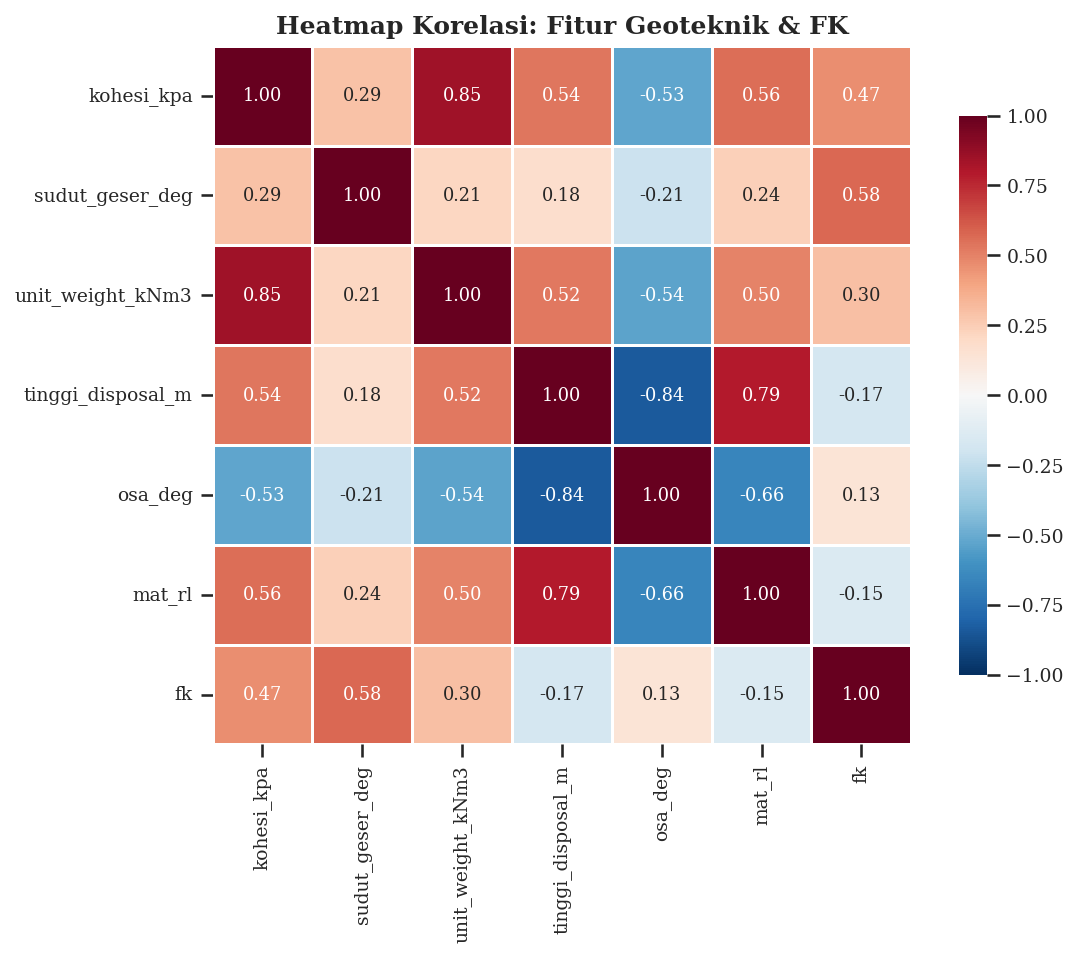


Korelasi univariat terhadap FK (urutan arah untuk verifikasi constraint):
tinggi_disposal_m   -0.174953
mat_rl              -0.147894
osa_deg              0.133232
unit_weight_kNm3     0.301230
kohesi_kpa           0.467083
sudut_geser_deg      0.575306


In [4]:
print("\n" + "=" * 70)
print("STATISTIK DESKRIPTIF")
print("=" * 70)
print(df[CONFIG["features"] + [CONFIG["target_regression"]]].describe().round(3))

n_fk_zero = (df[CONFIG["target_regression"]] == 0).sum()
print(f"\nJumlah baris dengan FK = 0: {n_fk_zero} "
      f"(dikonfirmasi valid, hasil aktual simulasi Slide2 -- lihat diskusi metodologi)")

fig, ax = plt.subplots(figsize=(8, 6.5))
corr_matrix = df[CONFIG["features"] + [CONFIG["target_regression"]]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1, annot_kws={"size": 8.5})
ax.set_title("Heatmap Korelasi: Fitur Geoteknik & FK", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "00_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nKorelasi univariat terhadap FK (urutan arah untuk verifikasi constraint):")
corr_fk = corr_matrix[CONFIG["target_regression"]].drop(CONFIG["target_regression"])
print(corr_fk.sort_values().to_string())

---
### SECTION 5 — PEMILIHAN FITUR, TARGET, & PERHITUNGAN LABEL RISIKO

**PENJELASAN**

Menetapkan variabel X (fitur input model) dan dua target: FK (angka kontinu, untuk model regresi) dan label risiko kategorikal Danger/Warning/Safe (untuk model klasifikasi), dihitung ulang dari nilai FK memakai ambang batas di CONFIG.

**DASAR / JUSTIFIKASI ILMIAH**

Label risiko dihitung ulang dari FK (bukan diambil dari kolom siap pakai) agar satu-satunya definisi ambang risiko benar-benar berada di CONFIG (Section 2) -- perubahan ambang batas di masa depan cukup dilakukan di satu tempat, dan pembaca dapat menelusuri asal-usul setiap label risiko secara transparan.

**MEKANISME**

Fungsi `compute_risk_label` menerapkan aturan: FK < `danger_max` -> Danger; `danger_max` <= FK < `warning_max` -> Warning; FK >= `warning_max` -> Safe. Fungsi ini diterapkan ke seluruh baris dataset memakai `.apply()`.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [5]:
def compute_risk_label(fk_value: float, thresholds: dict) -> str:
    """Mengklasifikasikan nilai FK menjadi label risiko kategorikal.

    Args:
        fk_value: Nilai Factor of Safety.
        thresholds: Dictionary berisi 'danger_max' dan 'warning_max'.

    Returns:
        Salah satu dari "Danger", "Warning", atau "Safe".
    """
    if fk_value < thresholds["danger_max"]:
        return "Danger"
    elif fk_value < thresholds["warning_max"]:
        return "Warning"
    return "Safe"


df["risk_label"] = df[CONFIG["target_regression"]].apply(
    lambda v: compute_risk_label(v, CONFIG["risk_thresholds"])
)

X = df[CONFIG["features"]].copy()
y_reg = df[CONFIG["target_regression"]].copy()
y_clf = df["risk_label"].copy()

print(f"Fitur (X)         : {CONFIG['features']}")
print(f"Target regresi    : {CONFIG['target_regression']}")
print(f"Target klasifikasi: risk_label (dihitung dari FK, threshold: {CONFIG['risk_thresholds']})")
print(f"\nDistribusi kelas risiko:")
print(y_clf.value_counts())
print(f"\nProporsi kelas (%):")
print((y_clf.value_counts(normalize=True) * 100).round(2))

Fitur (X)         : ['kohesi_kpa', 'sudut_geser_deg', 'unit_weight_kNm3', 'tinggi_disposal_m', 'osa_deg', 'mat_rl']
Target regresi    : fk
Target klasifikasi: risk_label (dihitung dari FK, threshold: {'danger_max': 1.1, 'warning_max': 1.3})

Distribusi kelas risiko:
risk_label
Safe       134
Danger     102
Warning     52
Name: count, dtype: int64

Proporsi kelas (%):
risk_label
Safe       46.53
Danger     35.42
Warning    18.06
Name: proportion, dtype: float64


---
### SECTION 6 — PEMBAGIAN DATA (STRATIFIED TRAIN-TEST SPLIT)

**PENJELASAN**

Membagi dataset menjadi data latih (training set, 80%) dan data uji (test set, 20%) yang tidak pernah dilihat model selama proses pelatihan -- data uji inilah yang dipakai untuk menilai performa model secara jujur.

**DASAR / JUSTIFIKASI ILMIAH**

Karena dataset ini cross-sectional (bukan deret waktu, lihat Section 3), strategi split yang tepat adalah acak/stratified -- mengikuti metodologi studi acuan (Meizhou, Surrogate-Li, GBM-Zhou) yang seluruhnya memakai skema serupa, BUKAN split kronologis seperti pada pipeline NARX (yang memang deret waktu).

**MEKANISME**

`train_test_split` dengan parameter `stratify=y_clf` memastikan proporsi setiap kelas risiko (termasuk kelas minoritas) tetap terjaga sama antara training set dan test set -- penting karena distribusi kelas risiko tidak seimbang.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [6]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=CONFIG["test_size"],
    stratify=y_clf,
    random_state=RANDOM_SEED,
)

print("\n" + "=" * 70)
print("PEMBAGIAN DATASET (Stratified Train-Test Split)")
print("=" * 70)
print(f"Training set : {len(X_train)} sampel ({len(X_train) / len(X) * 100:.1f}%)")
print(f"Test set     : {len(X_test)} sampel ({len(X_test) / len(X) * 100:.1f}%)")
print(f"\nDistribusi kelas risiko -- Training set:")
print(y_clf_train.value_counts(normalize=True).round(3))
print(f"\nDistribusi kelas risiko -- Test set:")
print(y_clf_test.value_counts(normalize=True).round(3))


PEMBAGIAN DATASET (Stratified Train-Test Split)
Training set : 230 sampel (79.9%)
Test set     : 58 sampel (20.1%)

Distribusi kelas risiko -- Training set:
risk_label
Safe       0.465
Danger     0.352
Warning    0.183
Name: proportion, dtype: float64

Distribusi kelas risiko -- Test set:
risk_label
Safe       0.466
Danger     0.362
Warning    0.172
Name: proportion, dtype: float64


---
### SECTION 7 — TUNING HYPERPARAMETER MODEL REGRESI (OPTUNA + MONOTONIC CONSTRAINTS)

**PENJELASAN**

Mencari kombinasi hyperparameter XGBoost (kedalaman pohon, learning rate, jumlah pohon, dsb.) yang menghasilkan performa terbaik, memakai pencarian otomatis berbasis Bayesian optimization (Optuna), bukan dicoba manual satu per satu.

**DASAR / JUSTIFIKASI ILMIAH**

Grid search manual mengevaluasi kombinasi hyperparameter secara menyeluruh pada titik-titik tetap, memboroskan komputasi pada wilayah yang jelas tidak menjanjikan. Optuna memakai *Tree-structured Parzen Estimator* yang memodelkan hubungan hyperparameter-performa secara probabilistik, mengarahkan pencarian ke wilayah yang lebih menjanjikan berdasarkan hasil trial sebelumnya -- pendekatan yang diadopsi langsung dari kerangka *Interpretable and Calibrated XGBoost Framework* untuk slope stability.

**MEKANISME**

Setiap trial Optuna: (1) mengambil sampel kombinasi hyperparameter dari ruang pencarian, (2) MENERAPKAN monotonic constraint yang sama sejak awal pencarian (bukan ditambahkan belakangan setelah hyperparameter optimal ditemukan tanpa constraint), (3) mengevaluasi performa via 5-fold cross-validation (bukan satu validation split tunggal, mengurangi risiko memilih hyperparameter yang kebetulan cocok untuk satu partisi data), (4) mengembalikan RMSE rata-rata sebagai kriteria minimisasi. Proses ini diulang 100 kali (`optuna_n_trials`).

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [7]:
def build_xgb_regressor(params: dict) -> xgb.XGBRegressor:
    """Membangun XGBRegressor dengan monotonic constraints yang konsisten.

    Args:
        params: Dictionary hyperparameter (dari Optuna atau hasil akhir).

    Returns:
        Instance XGBRegressor yang siap dilatih (belum di-fit).
    """
    return xgb.XGBRegressor(
        objective="reg:squarederror",
        monotone_constraints=CONFIG["monotone_constraints"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **params,
    )


def optuna_objective_regression(trial: optuna.Trial) -> float:
    """Objective function Optuna untuk tuning XGBRegressor (kriteria: RMSE CV).

    Args:
        trial: Objek trial Optuna, dipakai untuk sampling hyperparameter
            dari search space yang didefinisikan di CONFIG.

    Returns:
        RMSE rata-rata 5-fold cross-validation (kriteria minimisasi).
    """
    space = CONFIG["optuna_search_space"]
    params = {
        "max_depth": trial.suggest_int("max_depth", *space["max_depth"]),
        "learning_rate": trial.suggest_float("learning_rate", *space["learning_rate"], log=True),
        "n_estimators": trial.suggest_int("n_estimators", *space["n_estimators"]),
        "subsample": trial.suggest_float("subsample", *space["subsample"]),
        "colsample_bytree": trial.suggest_float("colsample_bytree", *space["colsample_bytree"]),
        "min_child_weight": trial.suggest_int("min_child_weight", *space["min_child_weight"]),
        "reg_lambda": trial.suggest_float("reg_lambda", *space["reg_lambda"]),
        "reg_alpha": trial.suggest_float("reg_alpha", *space["reg_alpha"]),
    }

    kf = KFold(n_splits=CONFIG["n_cv_folds"], shuffle=True, random_state=RANDOM_SEED)
    fold_rmse = []
    for train_idx, val_idx in kf.split(X_train):
        model = build_xgb_regressor(params)
        model.fit(X_train.iloc[train_idx], y_reg_train.iloc[train_idx])
        pred = model.predict(X_train.iloc[val_idx])
        fold_rmse.append(np.sqrt(mean_squared_error(y_reg_train.iloc[val_idx], pred)))

    return float(np.mean(fold_rmse))


print("\n" + "=" * 70)
print(f"TUNING HYPERPARAMETER REGRESI -- OPTUNA ({CONFIG['optuna_n_trials']} TRIAL, "
      f"{CONFIG['n_cv_folds']}-FOLD CV)")
print("=" * 70)

study_regression = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_regression.optimize(optuna_objective_regression, n_trials=CONFIG["optuna_n_trials"],
                           show_progress_bar=False)

print(f"\nJumlah trial selesai   : {len(study_regression.trials)}")
print(f"RMSE CV terbaik        : {study_regression.best_value:.5f}")
print(f"\nHyperparameter terbaik:")
for key, val in study_regression.best_params.items():
    print(f"  {key:<20}: {val}")


TUNING HYPERPARAMETER REGRESI -- OPTUNA (100 TRIAL, 5-FOLD CV)

Jumlah trial selesai   : 100
RMSE CV terbaik        : 0.09809

Hyperparameter terbaik:
  max_depth           : 9
  learning_rate       : 0.1119262454385193
  n_estimators        : 815
  subsample           : 0.588919714382087
  colsample_bytree    : 0.7549811026511591
  min_child_weight    : 1
  reg_lambda          : 1.1801094545220905
  reg_alpha           : 0.15847588632586987


---
### SECTION 8 — TRAINING MODEL REGRESI FK FINAL

**PENJELASAN**

Melatih model XGBoost final memakai hyperparameter terbaik hasil Optuna (Section 7), kali ini pada SELURUH data training (bukan hanya satu fold cross-validation).

**DASAR / JUSTIFIKASI ILMIAH**

Hyperparameter terbaik dipilih berdasar rata-rata performa lintas 5 fold -- setelah keputusan hyperparameter final ditetapkan, model final memanfaatkan seluruh data training yang tersedia (bukan hanya 4/5 bagian dari satu fold) untuk estimasi parameter akhir, memaksimalkan penggunaan data.

**MEKANISME**

`build_xgb_regressor` dipanggil dengan `BEST_PARAMS_REGRESSION` (hasil Optuna) dan `monotone_constraints` yang identik dengan tahap tuning, lalu `.fit()` dijalankan pada `X_train`/`y_reg_train` penuh. Waktu training diukur (`time.perf_counter()`) untuk pelaporan efisiensi komputasi (Section 9C) -- pengukuran ini murni instrumentasi, TIDAK memengaruhi proses training itu sendiri.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [8]:
BEST_PARAMS_REGRESSION = study_regression.best_params

final_regressor = build_xgb_regressor(BEST_PARAMS_REGRESSION)

_t_start = time.perf_counter()
final_regressor.fit(X_train, y_reg_train)
training_time_regressor_sec = time.perf_counter() - _t_start

print("\n" + "=" * 70)
print("MODEL REGRESI FK FINAL -- TERLATIH")
print("=" * 70)
print(f"Hyperparameter final: {BEST_PARAMS_REGRESSION}")
print(f"Monotonic constraints: {CONFIG['monotone_constraints']}")
print(f"Jumlah pohon (n_estimators): {final_regressor.n_estimators}")
print(f"Waktu training (Regresi)   : {training_time_regressor_sec:.4f} detik")


MODEL REGRESI FK FINAL -- TERLATIH
Hyperparameter final: {'max_depth': 9, 'learning_rate': 0.1119262454385193, 'n_estimators': 815, 'subsample': 0.588919714382087, 'colsample_bytree': 0.7549811026511591, 'min_child_weight': 1, 'reg_lambda': 1.1801094545220905, 'reg_alpha': 0.15847588632586987}
Monotonic constraints: (1, 1, 0, -1, -1, -1)
Jumlah pohon (n_estimators): 815
Waktu training (Regresi)   : 0.1577 detik


---
### SECTION 9A — EVALUASI MODEL REGRESI — METRIK UTAMA (R² & RMSE)

**PENJELASAN**

Mengukur seberapa akurat model regresi memprediksi nilai FK pada data uji (test set) yang belum pernah dilihat model, memakai dua metrik utama: R² (Coefficient of Determination) dan RMSE (Root Mean Squared Error).

**DASAR / JUSTIFIKASI ILMIAH**

R² dan RMSE dipilih sebagai metrik EVALUASI UTAMA karena keduanya paling umum dilaporkan pada studi acuan slope stability berbasis machine learning (Meizhou Landslide R²=0,96; Surrogate-Li R²=0,9989) sehingga hasil penelitian ini dapat dibandingkan langsung dengan literatur. R² mengukur proporsi variansi FK yang berhasil dijelaskan model (1,0 = sempurna); RMSE mengukur besar kesalahan dalam satuan FK yang sama dengan data asli, dengan bobot lebih berat pada kesalahan besar dibanding kesalahan kecil.

**MEKANISME**

`r2_score` dan `mean_squared_error` (di-akar-kuadratkan) dari scikit-learn dihitung antara `y_reg_test` (nilai FK aktual) dan `y_reg_pred` (hasil prediksi `final_regressor`). Waktu inferensi (prediksi) turut diukur untuk pelaporan efisiensi (Section 9C).

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

R² >= 0,80 dan RMSE serendah mungkin (dibandingkan skala FK yang berkisar 0-2,2) menunjukkan model regresi layak dipakai. Metrik pelengkap (MAE, MAPE, VAF, Physics Inconsistency Index) tetap dihitung pada Section 9B sebagai analisis tambahan yang lebih rinci, namun R² dan RMSE adalah acuan kelayakan utama.

In [9]:
def compute_vaf(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Menghitung Variance Account For (VAF) dalam persen.

    VAF = (1 - Var(actual - predicted) / Var(actual)) x 100. Metrik ini
    dipakai studi M5Rules-GA (Prediction of Slope Failure in Open-Pit
    Mines) sebagai pelengkap R² untuk evaluasi model slope stability.
    """
    return float((1 - np.var(actual - predicted) / np.var(actual)) * 100)


def compute_physics_inconsistency_index(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Menghitung Physics Inconsistency Index (PI).

    Prediksi diurutkan berdasarkan nilai AKTUAL, kemudian dihitung rata-rata
    pelanggaran arah monoton (penurunan prediksi padahal aktual naik) --
    mengikuti definisi pada kerangka Knowledge-Guided Machine Learning untuk
    slope stability prediction.

    Args:
        actual: Nilai FK aktual.
        predicted: Nilai FK hasil prediksi model.

    Returns:
        PI (mendekati 0 = konsisten fisika; makin besar = makin banyak
        pelanggaran monotonisitas).
    """
    order = np.argsort(actual)
    pred_sorted = predicted[order]
    diffs = np.diff(pred_sorted)
    violations = np.maximum(-diffs, 0)
    return float(np.mean(violations))


_t_start = time.perf_counter()
y_reg_pred = final_regressor.predict(X_test)
inference_time_regressor_sec = time.perf_counter() - _t_start

r2 = r2_score(y_reg_test, y_reg_pred)
rmse = float(np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)))
mae = float(mean_absolute_error(y_reg_test, y_reg_pred))
mape = float(np.mean(np.abs((y_reg_test.values - y_reg_pred) / y_reg_test.values)) * 100)
vaf = compute_vaf(y_reg_test.values, y_reg_pred)
pi_index = compute_physics_inconsistency_index(y_reg_test.values, y_reg_pred)

regression_metrics = {
    "r2": r2, "rmse": rmse, "mae": mae, "mape": mape, "vaf": vaf,
    "physics_inconsistency_index": pi_index,
}

print("\n" + "=" * 70)
print("HASIL EVALUASI MODEL REGRESI FK (Test Set)")
print("=" * 70)
for metric, value in regression_metrics.items():
    print(f"  {metric.upper():<32}: {value:.5f}")

print(f"\nBenchmark literatur -- Meizhou (Khan et al.): R2=0,96 | "
      f"Surrogate-Li: R2=0,9989")
print(f"Model kita: R2={r2:.4f} "
      f"({'SEBANDING/MENDEKATI' if r2 >= 0.90 else 'DI BAWAH'} benchmark literatur)")

print(f"\nWaktu inferensi (Regresi, {len(X_test)} sampel): "
      f"{inference_time_regressor_sec:.6f} detik "
      f"({inference_time_regressor_sec / len(X_test) * 1000:.4f} ms/sampel)")

print("\n" + "=" * 70)
print("METRIK UTAMA (Evaluasi Regresi)")
print("=" * 70)
print(f"  R2 (Coefficient of Determination) : {r2:.5f}")
print(f"  RMSE (Root Mean Squared Error)     : {rmse:.5f}")


HASIL EVALUASI MODEL REGRESI FK (Test Set)
  R2                              : 0.96305
  RMSE                            : 0.08481
  MAE                             : 0.06254
  MAPE                            : 6.65407
  VAF                             : 96.39319
  PHYSICS_INCONSISTENCY_INDEX     : 0.03706

Benchmark literatur -- Meizhou (Khan et al.): R2=0,96 | Surrogate-Li: R2=0,9989
Model kita: R2=0.9630 (SEBANDING/MENDEKATI benchmark literatur)

Waktu inferensi (Regresi, 58 sampel): 0.003869 detik (0.0667 ms/sampel)

METRIK UTAMA (Evaluasi Regresi)
  R2 (Coefficient of Determination) : 0.96305
  RMSE (Root Mean Squared Error)     : 0.08481


---
### SECTION 10 — VISUALISASI EVALUASI REGRESI

**PENJELASAN**

Melengkapi metrik angka (Section 9) dengan tiga diagnostik visual terpisah: (A) scatter plot prediksi vs aktual, (B) plot residual, (C) feature importance berbasis Gain bawaan XGBoost.

**DASAR / JUSTIFIKASI ILMIAH**

Scatter plot prediksi-vs-aktual dengan garis referensi ideal (y=x) adalah visualisasi standar validasi model regresi -- penyimpangan sistematis dari garis ini mengindikasikan bias. Plot residual memverifikasi tidak adanya *heteroskedastisitas* (pola corong yang menandakan error membesar seiring nilai prediksi). Feature importance Gain memberi gambaran awal sebelum interpretasi mendalam via SHAP (Section 11) -- CATATAN PENTING: Gain dan SHAP adalah dua metrik berbeda secara matematis dan dapat menghasilkan urutan fitur yang berbeda; SHAP (bukan Gain) adalah acuan interpretasi utama penelitian ini karena sifat aksiomatiknya (lihat Section 11).

**MEKANISME**

Setiap grafik dirender sebagai figure tersendiri (bukan digabung dalam satu panel) agar setiap visualisasi dapat langsung dipakai sebagai gambar mandiri di skripsi/publikasi, dengan resolusi tinggi (300 dpi). Gaya visual (warna, marker, font) dipertahankan identik dengan versi sebelumnya.

**IMPLEMENTASI**

Lihat sel kode di bawah.

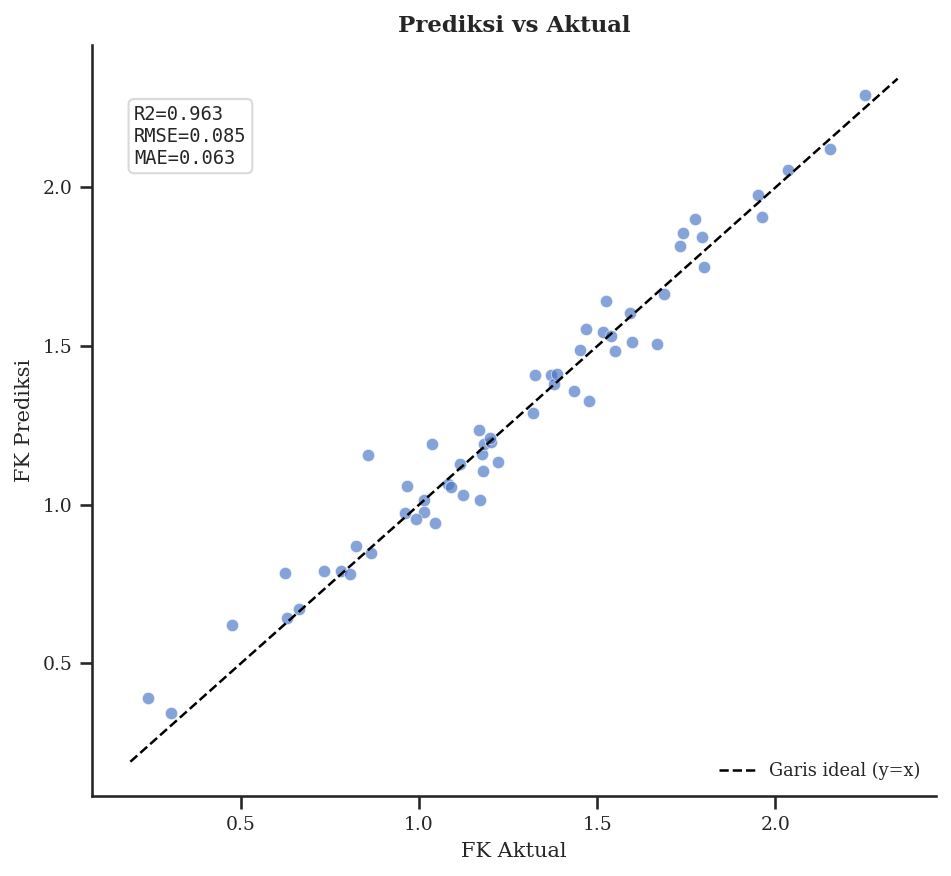

In [10]:
# -- (A) Scatter plot: Prediksi vs Aktual ------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_reg_test, y_reg_pred, color="#4472c4", alpha=0.65, s=35,
           edgecolor="white", linewidth=0.4)
lims = [min(y_reg_test.min(), y_reg_pred.min()) - 0.05,
        max(y_reg_test.max(), y_reg_pred.max()) + 0.05]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, label="Garis ideal (y=x)")
ax.text(0.05, 0.92, f"R2={r2:.3f}\nRMSE={rmse:.3f}\nMAE={mae:.3f}",
        transform=ax.transAxes, va="top", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="lightgray"))
ax.set_xlabel("FK Aktual"); ax.set_ylabel("FK Prediksi")
ax.set_title("Prediksi vs Aktual", fontweight="bold")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "01a_prediksi_vs_aktual.png", dpi=300, bbox_inches="tight")
plt.show()

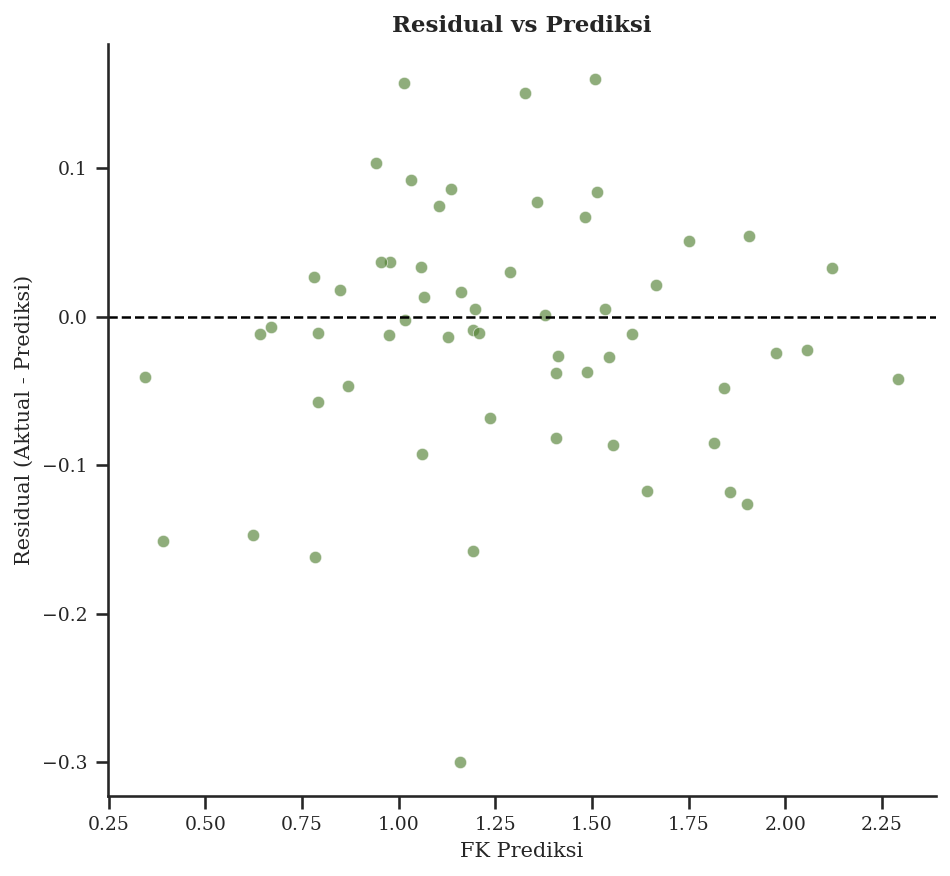

In [11]:
# -- (B) Residual plot --------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6))
residuals = y_reg_test.values - y_reg_pred
ax.scatter(y_reg_pred, residuals, color="#548235", alpha=0.65, s=35,
           edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("FK Prediksi"); ax.set_ylabel("Residual (Aktual - Prediksi)")
ax.set_title("Residual vs Prediksi", fontweight="bold")
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "01b_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

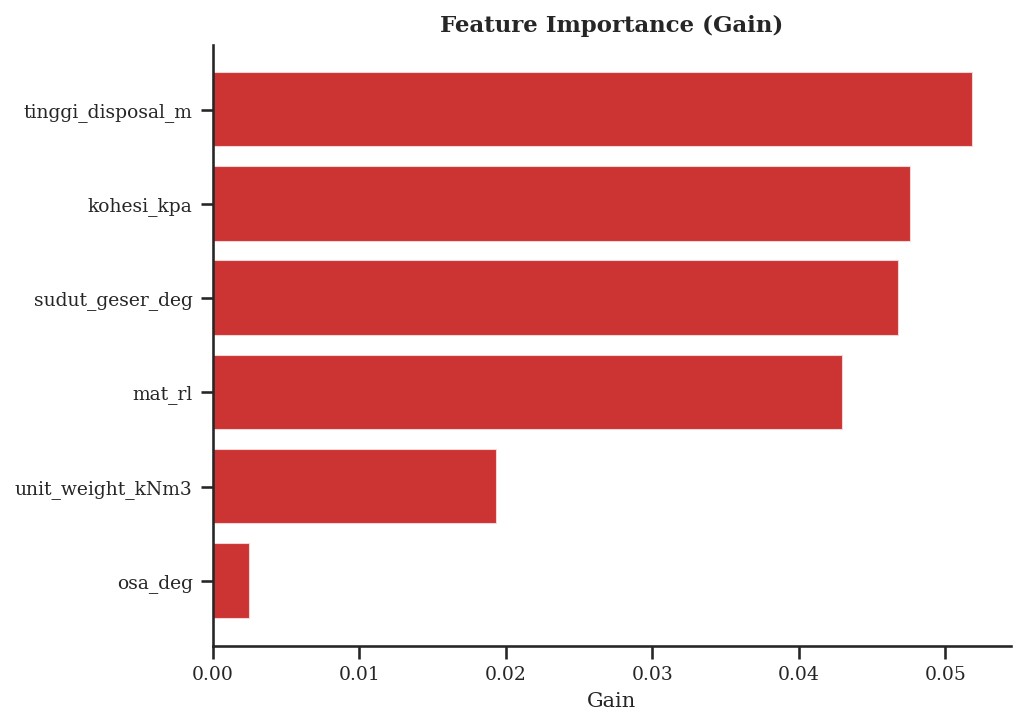

In [12]:
# -- (C) Feature Importance (Gain) --------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
importance = final_regressor.get_booster().get_score(importance_type="gain")
importance_df = pd.DataFrame(
    {"feature": list(importance.keys()), "gain": list(importance.values())}
).sort_values("gain", ascending=True)
ax.barh(importance_df["feature"], importance_df["gain"], color="#c00000", alpha=0.8)
ax.set_xlabel("Gain")
ax.set_title("Feature Importance (Gain)", fontweight="bold")
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "01c_feature_importance_gain.png", dpi=300, bbox_inches="tight")
plt.show()

---
### SECTION 11A — INTERPRETASI MODEL — PERHITUNGAN SHAP VALUES

**PENJELASAN**

Menghitung kontribusi setiap fitur terhadap SETIAP prediksi individual model regresi FK, memakai metode SHAP (SHapley Additive exPlanations).

**DASAR / JUSTIFIKASI ILMIAH**

Lundberg & Lee (2017) membuktikan secara matematis bahwa SHAP value adalah SATU-SATUNYA metode atribusi fitur yang memenuhi tiga properti aksiomatik dari teori permainan (Shapley value): *local accuracy* (jumlah kontribusi = selisih prediksi dari nilai dasar), *missingness* (fitur yang tidak berpengaruh mendapat kontribusi nol), dan *consistency* (jika model berubah sehingga fitur berkontribusi lebih besar, SHAP value fitur itu tidak boleh menurun). `TreeExplainer` memanfaatkan struktur pohon XGBoost untuk menghitung SHAP secara EKSAK (bukan aproksimasi), jauh lebih efisien dibanding Kernel SHAP model-agnostic.

**MEKANISME**

`shap.TreeExplainer(final_regressor)` membangun explainer dari model regresi FINAL (hasil Optuna, Section 8) -- BUKAN model sementara. `.shap_values(X_test)` menghitung kontribusi setiap fitur untuk setiap sampel di test set. Nilai rata-rata |SHAP| di seluruh sampel (`mean_abs_shap`) menghasilkan ranking kepentingan fitur secara global.

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Karena monotonic constraint diterapkan sejak training (Section 7-8), arah SHAP untuk fitur ber-constraint DIJAMIN secara struktural konsisten dengan prinsip fisika yang ditetapkan -- diverifikasi eksplisit di Section 11D.

In [13]:
explainer = shap.TreeExplainer(final_regressor)
shap_values = explainer.shap_values(X_test)

print("\n" + "=" * 70)
print("SHAP VALUES BERHASIL DIHITUNG (TreeExplainer)")
print("=" * 70)
print(f"Shape SHAP values: {shap_values.shape}  (n_test, n_features)")
print(f"Expected value (base value): {explainer.expected_value:.4f}")

mean_abs_shap = pd.DataFrame({
    "feature": CONFIG["features"],
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
print("\nRanking kontribusi rata-rata (|SHAP|):")
print(mean_abs_shap.to_string(index=False))


SHAP VALUES BERHASIL DIHITUNG (TreeExplainer)
Shape SHAP values: (58, 6)  (n_test, n_features)
Expected value (base value): 1.2861

Ranking kontribusi rata-rata (|SHAP|):
          feature  mean_abs_shap
       kohesi_kpa       0.272226
           mat_rl       0.163020
tinggi_disposal_m       0.136180
  sudut_geser_deg       0.133267
          osa_deg       0.074165
 unit_weight_kNm3       0.024798


---
### SECTION 11B — SHAP FEATURE IMPORTANCE (BAR CHART)

**PENJELASAN**

Memvisualisasikan ranking rata-rata |SHAP| (Section 11A) sebagai bar chart horizontal -- visualisasi UTAMA interpretasi model dalam penelitian ini.

**DASAR / JUSTIFIKASI ILMIAH**

Bar chart horizontal terurut adalah format standar pelaporan SHAP feature importance pada studi slope stability berbasis XGBoost/SHAP yang menjadi acuan penelitian ini (mis. *Sensitivity Analysis of Slope Stability Based on eXtreme Gradient Boosting and SHapley Additive exPlanations*) -- format ini dipilih karena menyampaikan ranking kepentingan fitur secara ringkas dan mudah dibaca, termasuk oleh pembaca tanpa latar belakang machine learning.

**MEKANISME**

Bar chart disusun dari `mean_abs_shap` (Section 11A), diurutkan menaik (fitur paling berpengaruh di posisi TERATAS) sesuai konvensi bar chart horizontal pada jurnal Q1.

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Fitur dengan bar terpanjang adalah fitur yang paling banyak berkontribusi terhadap variasi prediksi FK model. Bandingkan urutan ini dengan Section 10C (Gain) -- keduanya boleh berbeda (lihat catatan Section 10); SHAP adalah acuan interpretasi resmi.

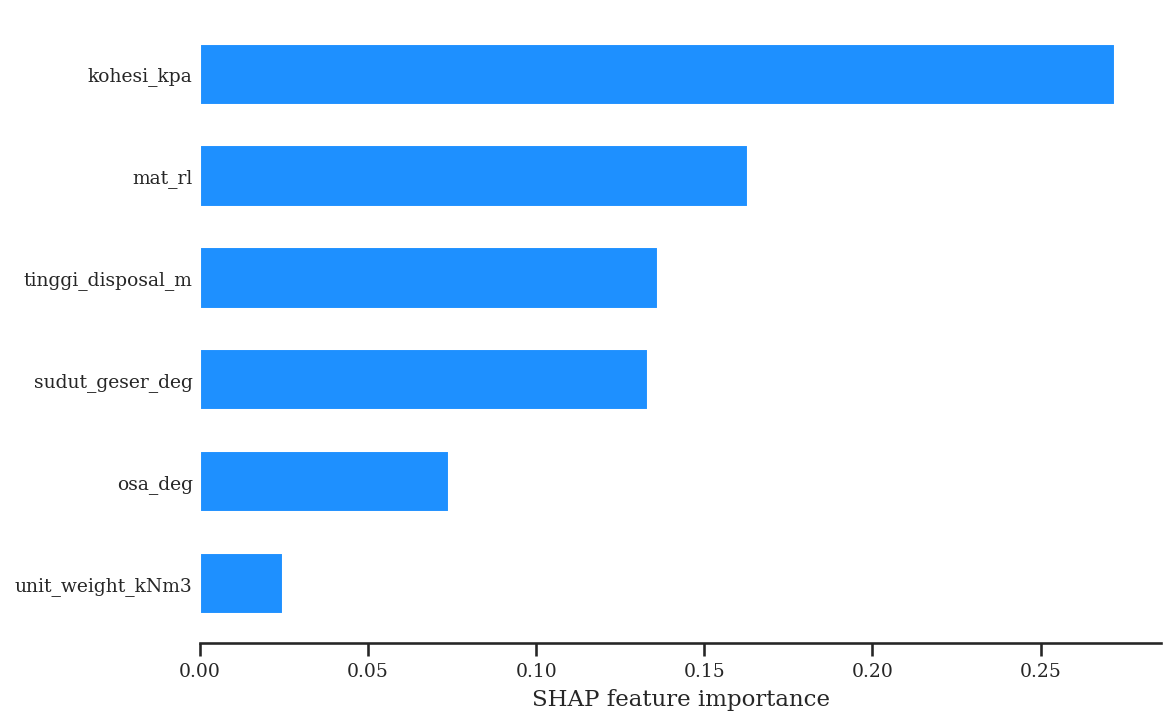

In [14]:
shap_bar_data = mean_abs_shap.sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_bar_data["feature"], shap_bar_data["mean_abs_shap"],
        color="#1E90FF", height=0.6)
ax.set_xlabel("SHAP feature importance", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "02a_shap_feature_importance.png",
            dpi=300, bbox_inches="tight")
plt.show()

---
### SECTION 11C — SHAP SUMMARY PLOT (BEESWARM) — ANALISIS TAMBAHAN

**PENJELASAN**

Melengkapi bar chart ranking (Section 11B, yang hanya menunjukkan RATA-RATA pengaruh) dengan sebaran SHAP value seluruh sampel test set untuk setiap fitur sekaligus -- menunjukkan arah dan variasi pengaruh, bukan hanya besarnya.

**DASAR / JUSTIFIKASI ILMIAH**

Beeswarm plot adalah visualisasi standar SHAP (Lundberg et al., 2020) yang memberi gambaran lebih kaya dibanding bar chart rata-rata: warna titik menunjukkan nilai fitur aktual (merah = tinggi, biru = rendah), posisi horizontal menunjukkan besar & arah kontribusi terhadap prediksi FK.

**MEKANISME**

`shap.summary_plot` bawaan pustaka SHAP dipakai langsung (bukan implementasi manual) untuk menjamin akurasi visual terhadap nilai SHAP yang sesungguhnya.

**IMPLEMENTASI**

Lihat sel kode di bawah.

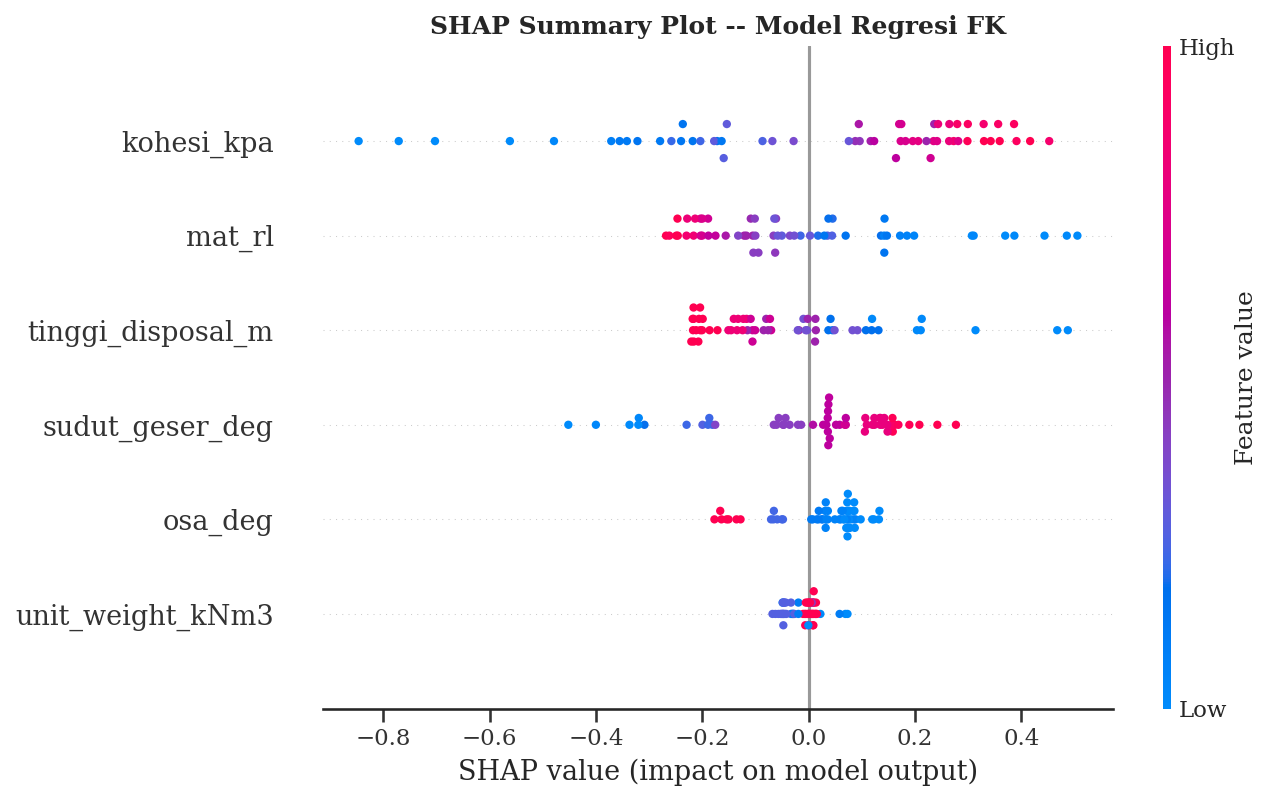

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
shap.summary_plot(shap_values, X_test, feature_names=CONFIG["features"],
                   show=False, plot_size=None)
plt.title("SHAP Summary Plot -- Model Regresi FK", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "02_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

---
### SECTION 11D — SHAP DEPENDENCE PLOT & VERIFIKASI MONOTONIC CONSTRAINT

**PENJELASAN**

Memvisualisasikan hubungan antara nilai setiap fitur dan kontribusi SHAP-nya terhadap prediksi FK, seluruh fitur ditampilkan bersisian dalam satu grid agar mudah dibandingkan langsung -- lalu memverifikasi apakah arahnya benar-benar konsisten dengan monotonic constraint yang ditetapkan di CONFIG (Section 2).

**DASAR / JUSTIFIKASI ILMIAH**

Monotonic constraint XGBoost menjamin arah monoton terhadap PERUBAHAN SATU fitur dengan fitur lain tetap konstan -- pada data uji riil (banyak fitur berubah bersamaan), interaksi antar-fitur secara teori masih bisa menghasilkan pola yang tampak tidak monoton secara agregat. Verifikasi kuantitatif (korelasi Spearman antara nilai fitur dan SHAP value) memberi bukti langsung, bukan asumsi bahwa constraint otomatis menjamin perilaku agregat yang diinginkan.

**MEKANISME**

Untuk setiap fitur: scatter plot (nilai fitur pada sumbu X, SHAP value pada sumbu Y), dihitung korelasi Spearman, dibandingkan tandanya (+/-) dengan `monotone_constraints` yang diharapkan. Status "Konsisten"/"TIDAK Konsisten"/"Tanpa constraint" dicetak untuk setiap fitur. Seluruh fitur ditampilkan dalam satu grid (3 kolom) dalam satu figure.

**IMPLEMENTASI**

Lihat sel kode di bawah.

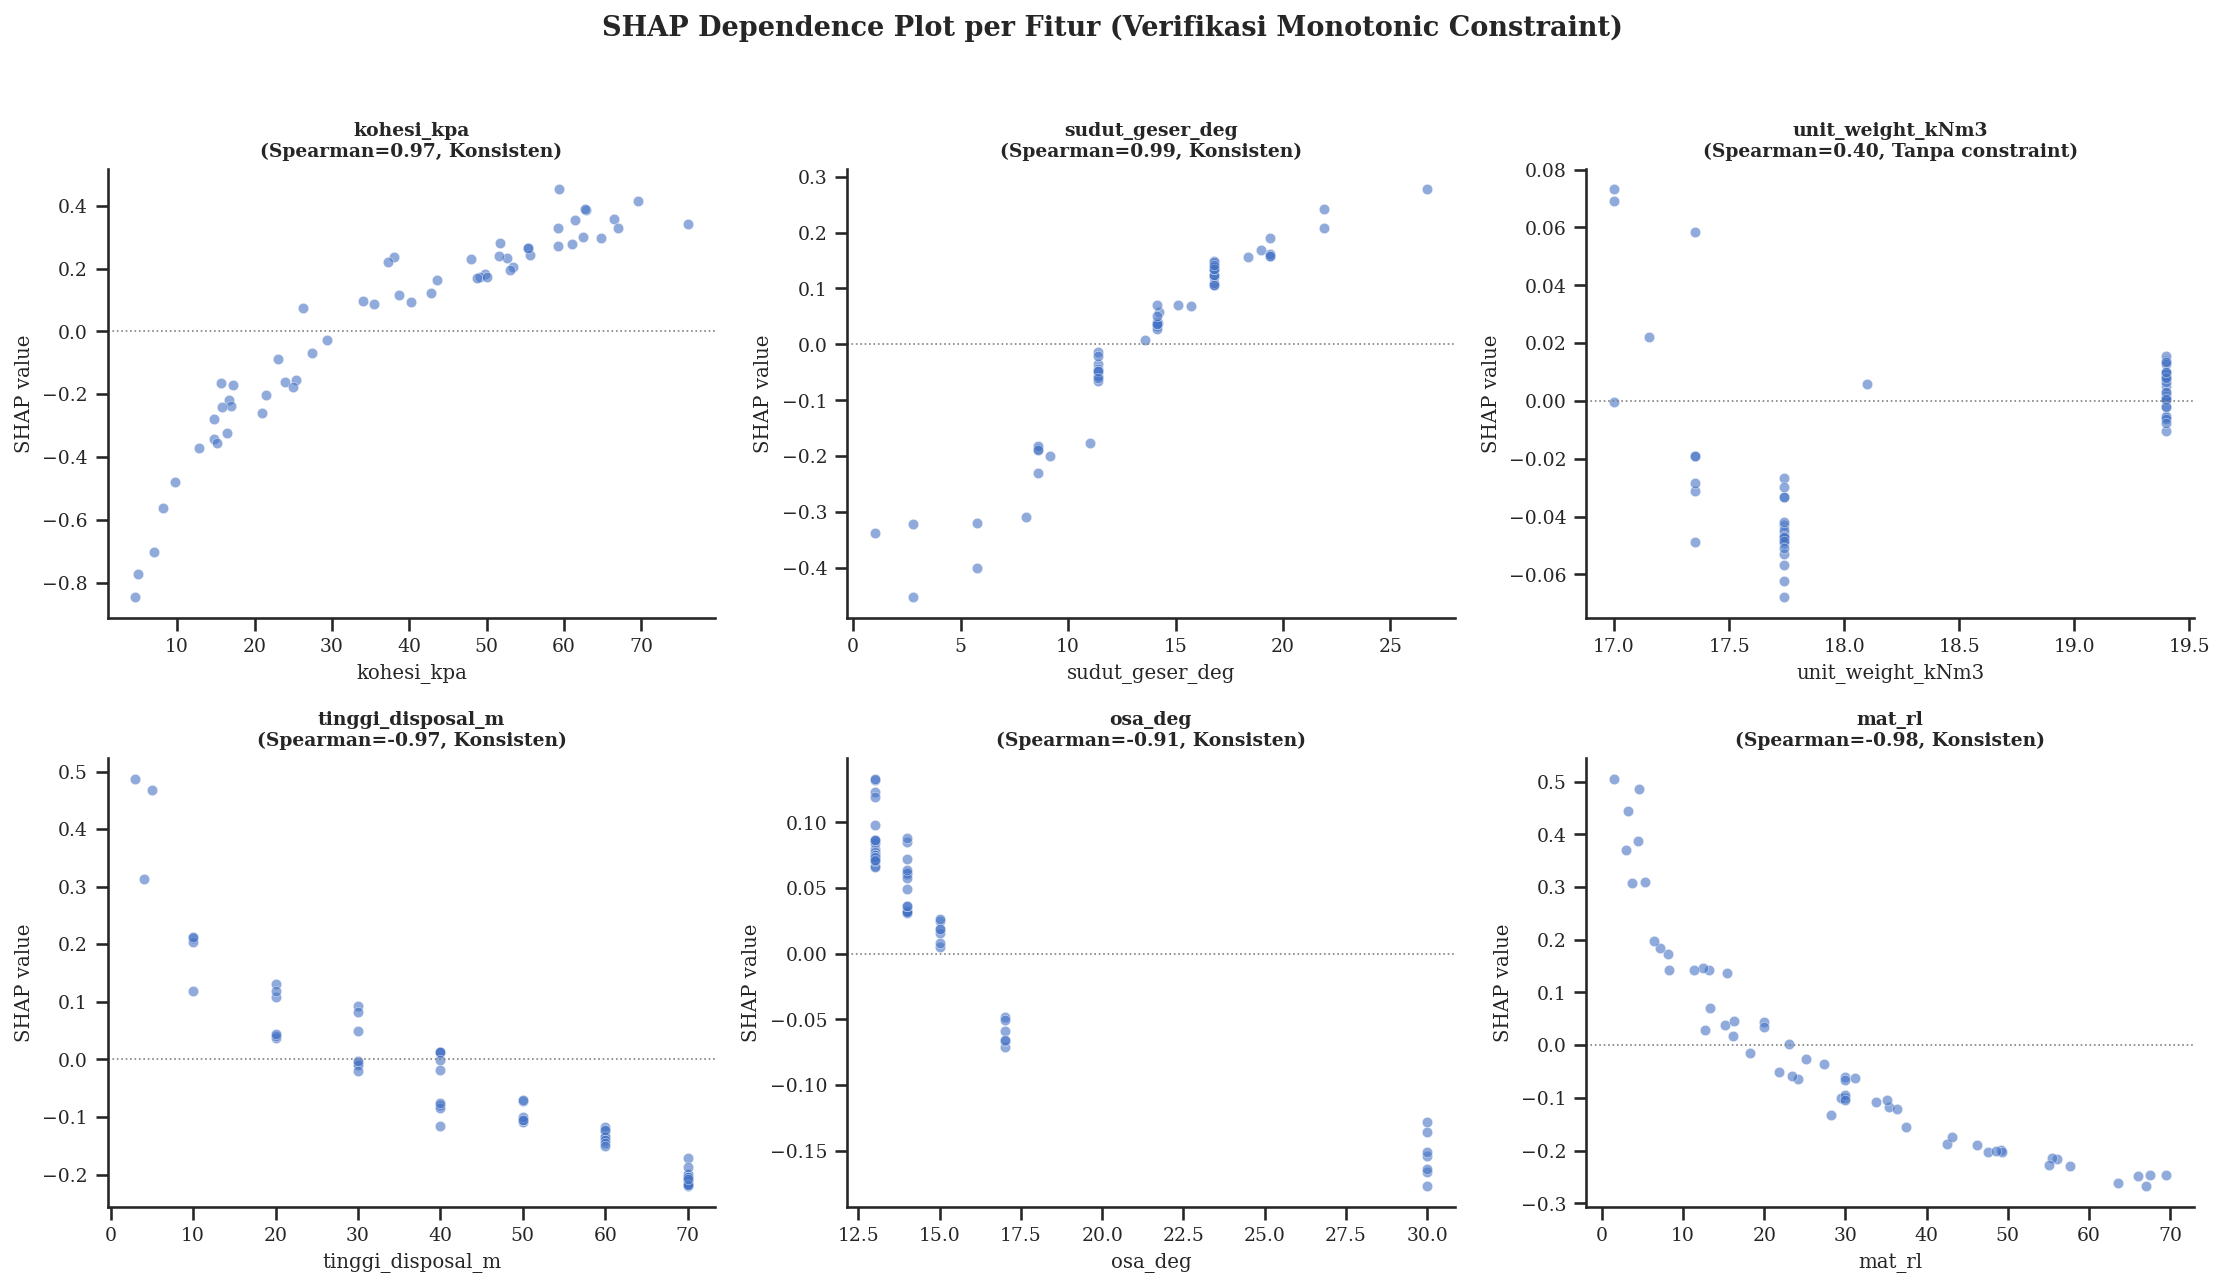


VERIFIKASI ARAH MONOTONIC CONSTRAINT VS SHAP DEPENDENCE
          feature  expected_direction  spearman_corr           status
       kohesi_kpa                   1          0.972        Konsisten
  sudut_geser_deg                   1          0.986        Konsisten
 unit_weight_kNm3                   0          0.400 Tanpa constraint
tinggi_disposal_m                  -1         -0.968        Konsisten
          osa_deg                  -1         -0.912        Konsisten
           mat_rl                  -1         -0.985        Konsisten


In [16]:
n_features_plot = len(CONFIG["features"])
n_cols = 3
n_rows = int(np.ceil(n_features_plot / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = axes.flatten()

constraint_verification = []
for idx, feature in enumerate(CONFIG["features"]):
    ax = axes[idx]
    feature_values = X_test[feature].values
    shap_feature = shap_values[:, idx]
    ax.scatter(feature_values, shap_feature, color="#4472c4", alpha=0.6, s=25,
               edgecolor="white", linewidth=0.3)
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel(feature, fontsize=9.5)
    ax.set_ylabel("SHAP value", fontsize=9.5)

    spearman_corr = pd.Series(feature_values).corr(pd.Series(shap_feature), method="spearman")
    expected_sign = CONFIG["monotone_constraints"][idx]
    if expected_sign == 0:
        status = "Tanpa constraint"
    elif np.sign(spearman_corr) == expected_sign:
        status = "Konsisten"
    else:
        status = "TIDAK Konsisten"
    constraint_verification.append({
        "feature": feature, "expected_direction": expected_sign,
        "spearman_corr": round(float(spearman_corr), 3), "status": status,
    })
    ax.set_title(f"{feature}\n(Spearman={spearman_corr:.2f}, {status})",
                 fontsize=9, fontweight="bold")

for idx in range(n_features_plot, len(axes)):
    axes[idx].axis("off")

plt.suptitle("SHAP Dependence Plot per Fitur (Verifikasi Monotonic Constraint)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "02b_shap_dependence.png", dpi=300, bbox_inches="tight")
plt.show()

verification_df = pd.DataFrame(constraint_verification)
print("\n" + "=" * 70)
print("VERIFIKASI ARAH MONOTONIC CONSTRAINT VS SHAP DEPENDENCE")
print("=" * 70)
print(verification_df.to_string(index=False))

---
### SECTION 11E — SHAP WATERFALL PLOT (INTERPRETASI SAMPEL INDIVIDUAL)

**PENJELASAN**

Melengkapi interpretasi global (Section 11A-D) dengan interpretasi LOKAL -- menjelaskan mengapa model menghasilkan prediksi FK tertentu untuk satu kombinasi parameter spesifik.

**DASAR / JUSTIFIKASI ILMIAH**

Interpretasi lokal relevan untuk aplikasi operasional -- menjelaskan hasil prediksi ke praktisi geoteknik non-ML secara konkret ("kenapa FK sampel ini rendah?") jauh lebih actionable dibanding hanya menunjukkan ranking rata-rata global.

**MEKANISME**

Dua sampel dipilih: FK terendah (paling berisiko) dan FK tertinggi (paling aman) dari hasil prediksi test set. `shap.waterfall_plot` menunjukkan bagaimana setiap fitur mendorong prediksi menjauh dari nilai dasar (*base value*, rata-rata FK training) menuju nilai prediksi akhir. Setiap sampel sudah dirender sebagai figure tersendiri.

**IMPLEMENTASI**

Lihat sel kode di bawah.

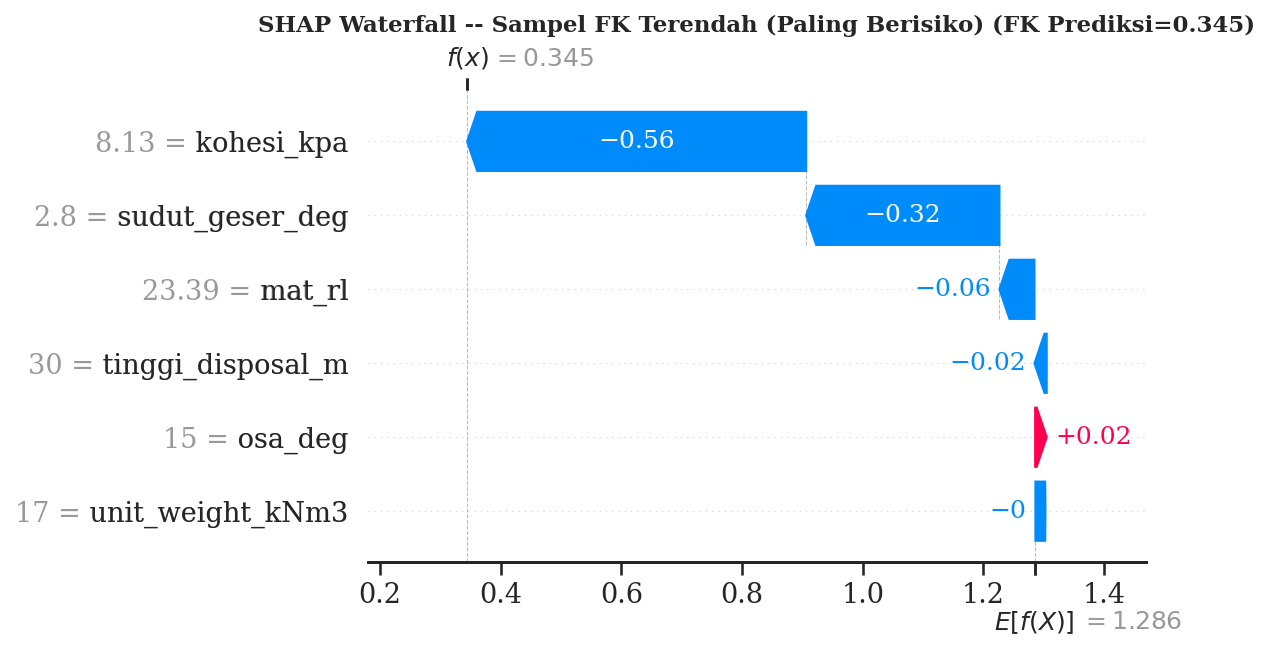

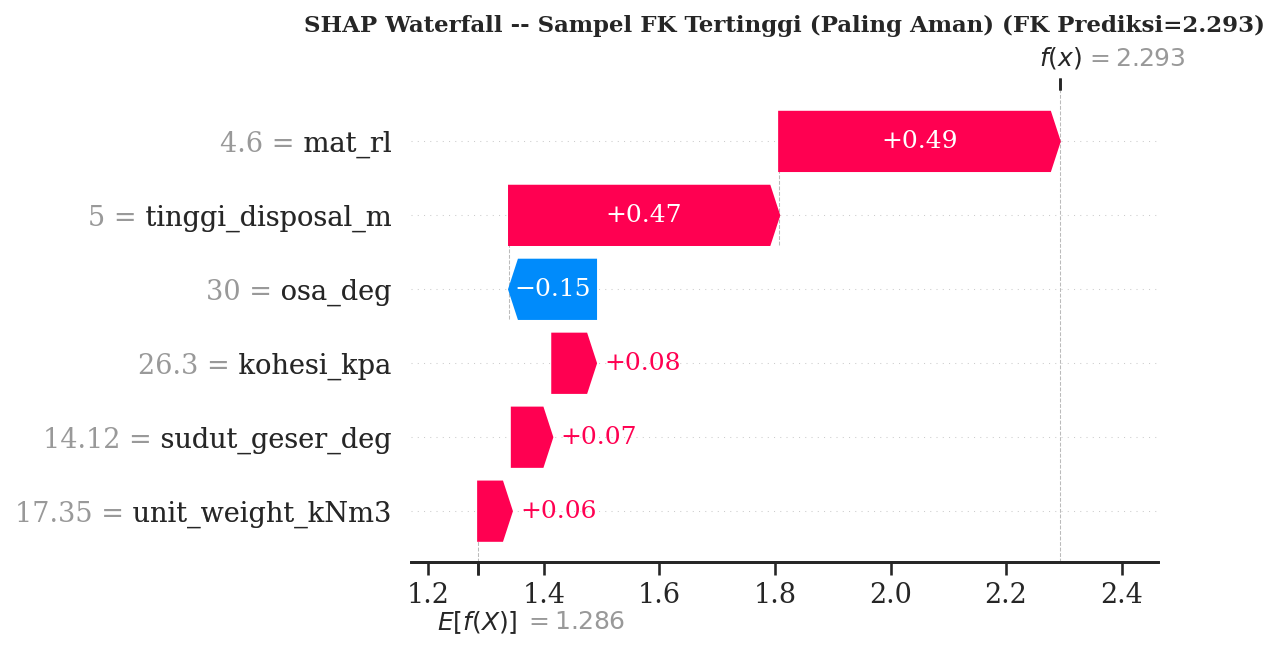

In [17]:
sample_idx_lowest = int(np.argmin(y_reg_pred))
sample_idx_highest = int(np.argmax(y_reg_pred))

for label, sample_idx in [("FK Terendah (Paling Berisiko)", sample_idx_lowest),
                            ("FK Tertinggi (Paling Aman)", sample_idx_highest)]:
    fig = plt.figure(figsize=(9, 5))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[sample_idx].values,
            feature_names=CONFIG["features"],
        ),
        show=False,
    )
    plt.title(f"SHAP Waterfall -- Sampel {label} (FK Prediksi={y_reg_pred[sample_idx]:.3f})",
              fontweight="bold", fontsize=11)
    plt.tight_layout()
    safe_label = label.split(" ")[1].lower()
    plt.savefig(CONFIG["output_dir"] / f"04_shap_waterfall_{safe_label}.png",
                dpi=300, bbox_inches="tight")
    plt.show()

---
### SECTION 12 — TUNING & TRAINING MODEL KLASIFIKASI RISIKO

**PENJELASAN**

Melatih model XGBoost KEDUA yang secara khusus memprediksi kategori risiko (Danger/Warning/Safe) sebagai target langsung -- bukan sekadar menerapkan ambang batas pasca-hoc pada hasil model regresi FK.

**DASAR / JUSTIFIKASI ILMIAH**

Model klasifikasi dilatih langsung pada label risiko sebagai target, memungkinkan model mempelajari batas keputusan yang optimal untuk tugas klasifikasi itu sendiri -- berpotensi lebih baik dibanding menerapkan threshold pasca-hoc pada prediksi regresi yang dioptimalkan untuk tujuan berbeda (minimasi RMSE, bukan akurasi klasifikasi). Stratified K-fold (bukan K-fold biasa) dipakai untuk tuning agar proporsi kelas terjaga di setiap fold, konsisten dengan alasan stratified split (Section 6) mengingat distribusi kelas risiko tidak seimbang.

**MEKANISME**

Proses identik dengan Section 7 (Optuna + monotonic constraint sejak awal pencarian), namun kriteria evaluasi tiap trial adalah akurasi rata-rata *stratified* 5-fold CV, bukan RMSE. Model final dilatih pada `BEST_PARAMS_CLASSIFICATION` hasil pencarian, memakai seluruh data training. Waktu training diukur untuk pelaporan efisiensi (Section 15).

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [18]:
risk_label_to_idx = {label: idx for idx, label in enumerate(CONFIG["risk_labels"])}
y_clf_train_encoded = y_clf_train.map(risk_label_to_idx)
y_clf_test_encoded = y_clf_test.map(risk_label_to_idx)


def build_xgb_classifier(params: dict) -> xgb.XGBClassifier:
    """Membangun XGBClassifier dengan monotonic constraints yang konsisten.

    Args:
        params: Dictionary hyperparameter (dari Optuna atau hasil akhir).

    Returns:
        Instance XGBClassifier yang siap dilatih (belum di-fit).
    """
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CONFIG["risk_labels"]),
        monotone_constraints=CONFIG["monotone_constraints"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **params,
    )


def optuna_objective_classification(trial: optuna.Trial) -> float:
    """Objective function Optuna untuk tuning XGBClassifier (kriteria: akurasi CV).

    Args:
        trial: Objek trial Optuna.

    Returns:
        Akurasi rata-rata stratified 5-fold cross-validation.
    """
    space = CONFIG["optuna_search_space"]
    params = {
        "max_depth": trial.suggest_int("max_depth", *space["max_depth"]),
        "learning_rate": trial.suggest_float("learning_rate", *space["learning_rate"], log=True),
        "n_estimators": trial.suggest_int("n_estimators", *space["n_estimators"]),
        "subsample": trial.suggest_float("subsample", *space["subsample"]),
        "colsample_bytree": trial.suggest_float("colsample_bytree", *space["colsample_bytree"]),
        "min_child_weight": trial.suggest_int("min_child_weight", *space["min_child_weight"]),
        "reg_lambda": trial.suggest_float("reg_lambda", *space["reg_lambda"]),
        "reg_alpha": trial.suggest_float("reg_alpha", *space["reg_alpha"]),
    }

    skf = StratifiedKFold(n_splits=CONFIG["n_cv_folds"], shuffle=True, random_state=RANDOM_SEED)
    fold_acc = []
    for train_idx, val_idx in skf.split(X_train, y_clf_train_encoded):
        model = build_xgb_classifier(params)
        model.fit(X_train.iloc[train_idx], y_clf_train_encoded.iloc[train_idx])
        pred = model.predict(X_train.iloc[val_idx])
        fold_acc.append(accuracy_score(y_clf_train_encoded.iloc[val_idx], pred))

    return float(np.mean(fold_acc))


print("\n" + "=" * 70)
print(f"TUNING HYPERPARAMETER KLASIFIKASI -- OPTUNA ({CONFIG['optuna_n_trials']} TRIAL)")
print("=" * 70)

study_classification = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_classification.optimize(optuna_objective_classification,
                                n_trials=CONFIG["optuna_n_trials"], show_progress_bar=False)

print(f"\nAkurasi CV terbaik: {study_classification.best_value:.4f}")
print(f"Hyperparameter terbaik:")
for key, val in study_classification.best_params.items():
    print(f"  {key:<20}: {val}")

BEST_PARAMS_CLASSIFICATION = study_classification.best_params
final_classifier = build_xgb_classifier(BEST_PARAMS_CLASSIFICATION)

_t_start = time.perf_counter()
final_classifier.fit(X_train, y_clf_train_encoded)
training_time_classifier_sec = time.perf_counter() - _t_start
print("\nModel klasifikasi risiko final -- terlatih.")
print(f"Waktu training (Klasifikasi): {training_time_classifier_sec:.4f} detik")


TUNING HYPERPARAMETER KLASIFIKASI -- OPTUNA (100 TRIAL)

Akurasi CV terbaik: 0.8739
Hyperparameter terbaik:
  max_depth           : 5
  learning_rate       : 0.29887406003733724
  n_estimators        : 1392
  subsample           : 0.860327948621566
  colsample_bytree    : 0.6935945536805687
  min_child_weight    : 2
  reg_lambda          : 0.9570761623706396
  reg_alpha           : 0.7719699229119532

Model klasifikasi risiko final -- terlatih.
Waktu training (Klasifikasi): 0.3018 detik


---
### SECTION 13A — EVALUASI MODEL KLASIFIKASI — METRIK LENGKAP

**PENJELASAN**

Mengukur performa model klasifikasi risiko pada data uji, memakai tujuh metrik: Accuracy, Cohen's Kappa, F1-Score, AUC-ROC, True Positive Rate (TPR/Recall), False Positive Rate (FPR), dan Confusion Matrix (Section 13B).

**DASAR / JUSTIFIKASI ILMIAH**

Accuracy saja dapat menyesatkan pada kelas tidak seimbang -- model yang selalu menebak kelas mayoritas bisa mencapai akurasi tinggi tanpa benar-benar prediktif. Cohen's Kappa mengoreksi kemungkinan kesepakatan acak (Landis & Koch, 1977: <0 Poor, 0-0,20 Slight, 0,21-0,40 Fair, 0,41-0,60 Moderate, 0,61-0,80 Substantial, 0,81-1,00 Almost Perfect; benchmark literatur GBM-Zhou et al. 2019 kappa=0,7324/Substantial). F1-Score menyeimbangkan presisi dan recall, penting saat kesalahan positif-palsu dan negatif-palsu sama-sama berbiaya (relevan untuk klasifikasi risiko keselamatan). AUC-ROC mengukur kemampuan model membedakan antar kelas pada seluruh ambang keputusan, diinterpretasi memakai pedoman Hosmer, Lemeshow & Sturdivant (2013): 0,70-0,80 = dapat diterima, >0,80 = baik. TPR (Recall) mengukur proporsi kasus berisiko yang berhasil terdeteksi -- krusial dalam konteks keselamatan tambang (FALSE NEGATIVE pada kelas Danger = risiko tidak terdeteksi). FPR mengukur proporsi kasus aman yang salah diklasifikasi berisiko.

**MEKANISME**

Karena klasifikasi ini multi-kelas (3 kelas: Danger/Warning/Safe), F1-Score, AUC-ROC, TPR, dan FPR dihitung per kelas lalu dirata-rata memakai skema *macro-average* (bobot sama untuk setiap kelas, TIDAK bias ke kelas mayoritas) -- konsisten dengan filosofi Cohen's Kappa yang sudah dipakai sebelumnya untuk mengatasi ketidakseimbangan kelas. AUC-ROC multi-kelas dihitung dengan skema *One-vs-Rest* (`ovr`). FPR dihitung per kelas dari confusion matrix (`FP / (FP + TN)`), lalu dirata-rata.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [19]:
_t_start = time.perf_counter()
y_clf_pred_encoded = final_classifier.predict(X_test)
inference_time_classifier_sec = time.perf_counter() - _t_start
y_clf_pred_proba = final_classifier.predict_proba(X_test)
y_clf_pred = pd.Series(y_clf_pred_encoded).map(
    {idx: label for label, idx in risk_label_to_idx.items()}
).values

accuracy = accuracy_score(y_clf_test_encoded, y_clf_pred_encoded)
kappa = cohen_kappa_score(y_clf_test_encoded, y_clf_pred_encoded)

if kappa < 0:
    kappa_interpretation = "Poor"
elif kappa < 0.20:
    kappa_interpretation = "Slight"
elif kappa < 0.40:
    kappa_interpretation = "Fair"
elif kappa < 0.60:
    kappa_interpretation = "Moderate"
elif kappa < 0.80:
    kappa_interpretation = "Substantial"
else:
    kappa_interpretation = "Almost Perfect"

classification_metrics = {
    "accuracy": float(accuracy), "cohen_kappa": float(kappa),
    "kappa_interpretation": kappa_interpretation,
}

print("\n" + "=" * 70)
print("HASIL EVALUASI MODEL KLASIFIKASI RISIKO (Test Set)")
print("=" * 70)
print(f"Accuracy      : {accuracy:.4f}")
print(f"Cohen's Kappa : {kappa:.4f} ({kappa_interpretation}, Landis & Koch 1977)")
print(f"Benchmark literatur (GBM-Zhou et al. 2019): kappa=0,7324 (Substantial)")


from sklearn.metrics import f1_score, recall_score, roc_auc_score

f1_macro = f1_score(y_clf_test_encoded, y_clf_pred_encoded, average="macro")
tpr_macro = recall_score(y_clf_test_encoded, y_clf_pred_encoded, average="macro")
auc_ovr = roc_auc_score(y_clf_test_encoded, y_clf_pred_proba, multi_class="ovr", average="macro")

cm_for_fpr = confusion_matrix(y_clf_test_encoded, y_clf_pred_encoded)
fpr_per_class = []
for k in range(len(CONFIG["risk_labels"])):
    fp = cm_for_fpr[:, k].sum() - cm_for_fpr[k, k]
    tn = cm_for_fpr.sum() - cm_for_fpr[k, :].sum() - cm_for_fpr[:, k].sum() + cm_for_fpr[k, k]
    fpr_per_class.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
fpr_macro = float(np.mean(fpr_per_class))

classification_metrics.update({
    "f1_macro": float(f1_macro), "tpr_macro_recall": float(tpr_macro),
    "auc_roc_ovr_macro": float(auc_ovr), "fpr_macro": fpr_macro,
})

print(f"F1-Score (macro)   : {f1_macro:.4f}")
print(f"AUC-ROC (OvR, macro): {auc_ovr:.4f}")
print(f"TPR / Recall (macro): {tpr_macro:.4f}")
print(f"FPR (macro)         : {fpr_macro:.4f}")
print(f"\nWaktu inferensi (Klasifikasi, {len(X_test)} sampel): "
      f"{inference_time_classifier_sec:.6f} detik "
      f"({inference_time_classifier_sec / len(X_test) * 1000:.4f} ms/sampel)")


HASIL EVALUASI MODEL KLASIFIKASI RISIKO (Test Set)
Accuracy      : 0.8966
Cohen's Kappa : 0.8369 (Almost Perfect, Landis & Koch 1977)
Benchmark literatur (GBM-Zhou et al. 2019): kappa=0,7324 (Substantial)
F1-Score (macro)   : 0.8662
AUC-ROC (OvR, macro): 0.9743
TPR / Recall (macro): 0.8804
FPR (macro)         : 0.0458

Waktu inferensi (Klasifikasi, 58 sampel): 0.007434 detik (0.1282 ms/sampel)


---
### SECTION 13B — CONFUSION MATRIX

**PENJELASAN**

Menampilkan tabel silang antara kelas risiko aktual dan kelas risiko hasil prediksi model, sebagai figure tersendiri.

**DASAR / JUSTIFIKASI ILMIAH**

Confusion matrix adalah cara paling transparan melihat POLA kesalahan klasifikasi -- metrik agregat (accuracy, F1) meringkas performa jadi satu angka, sementara confusion matrix menunjukkan PERSIS kelas mana yang paling sering tertukar dengan kelas lain (mis. apakah kesalahan lebih sering terjadi antara Warning-Safe yang berdekatan, atau -- lebih kritis -- antara Danger-Safe yang berjauhan).

**MEKANISME**

`confusion_matrix` dari scikit-learn dihitung antara label aktual dan prediksi (skala label asli: Danger/Warning/Safe), divisualisasikan sebagai heatmap.

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Diagonal utama = prediksi benar. Sel di luar diagonal, khususnya baris "Danger" yang diprediksi "Safe" (false negative kelas paling kritis), perlu mendapat perhatian khusus dalam konteks keselamatan.

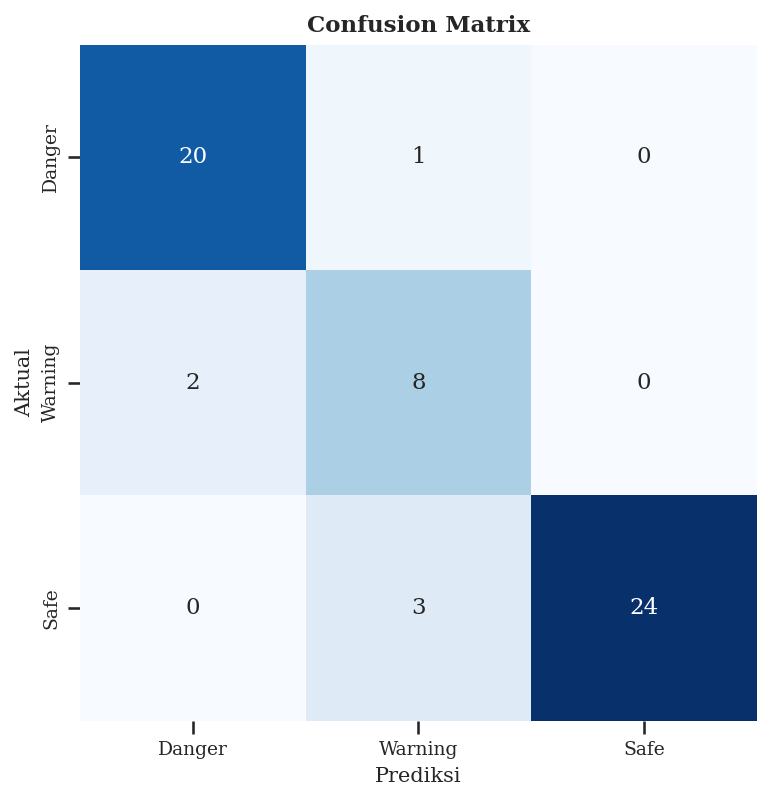

In [20]:
cm = confusion_matrix(y_clf_test, y_clf_pred, labels=CONFIG["risk_labels"])

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True, cbar=False,
            xticklabels=CONFIG["risk_labels"], yticklabels=CONFIG["risk_labels"], ax=ax,
            annot_kws={"size": 11})
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "03a_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

---
### SECTION 13C — RELIABILITY CURVE (KALIBRASI PROBABILITAS)

**PENJELASAN**

Memeriksa apakah probabilitas yang dikeluarkan model (mis. "85% yakin Danger") benar-benar mencerminkan frekuensi kejadian aktual, khusus untuk kelas Danger (kelas paling kritis).

**DASAR / JUSTIFIKASI ILMIAH**

Mengikuti kerangka *Interpretable and Calibrated XGBoost Framework* -- sebuah model dapat memiliki akurasi klasifikasi tinggi namun probabilitas yang dihasilkan tidak terkalibrasi (model "yakin 90%" padahal secara empiris hanya benar 60% dari kasus serupa). Ini penting untuk aplikasi *risk-informed* di mana probabilitas itu sendiri (bukan hanya label kelas) dipakai sebagai dasar keputusan operasional.

**MEKANISME**

Probabilitas prediksi kelas Danger dikelompokkan ke dalam 5 bin, lalu dibandingkan frekuensi aktual Danger di setiap bin terhadap probabilitas rata-rata bin tersebut. Garis putus-putus diagonal = kalibrasi sempurna (probabilitas = frekuensi aktual).

**IMPLEMENTASI**

Lihat sel kode di bawah.

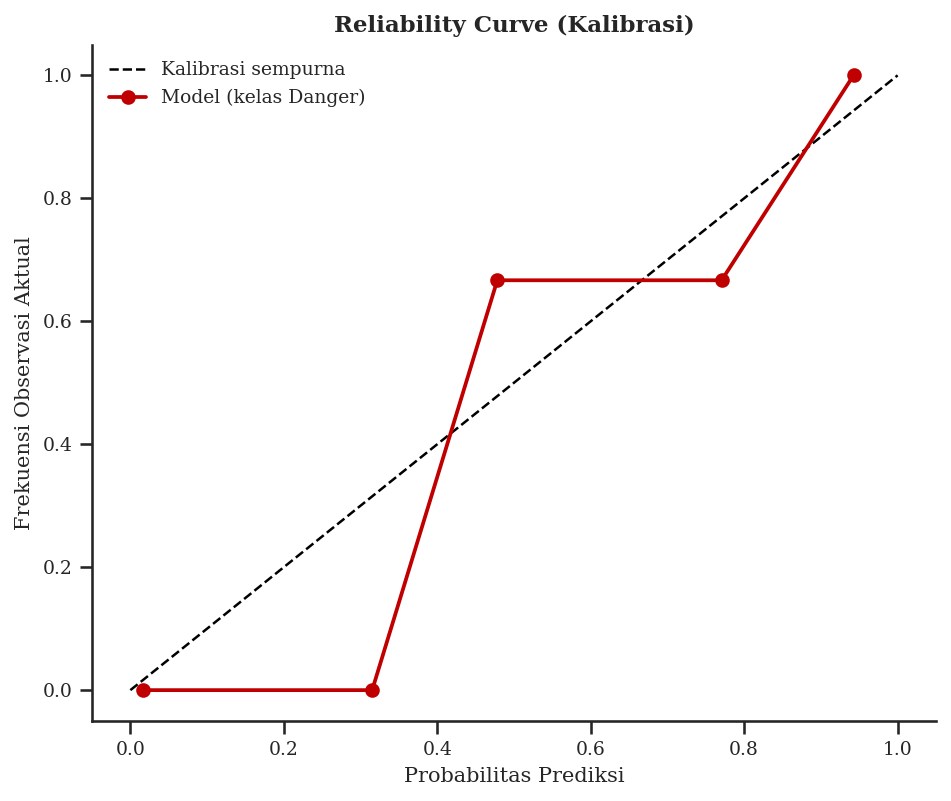

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
danger_idx = risk_label_to_idx["Danger"]
prob_danger = y_clf_pred_proba[:, danger_idx]
actual_danger = (y_clf_test_encoded == danger_idx).astype(int).values

n_bins = 5
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers, observed_freq = [], []
for i in range(n_bins):
    mask = (prob_danger >= bin_edges[i]) & (prob_danger < bin_edges[i + 1])
    if mask.sum() > 0:
        bin_centers.append(prob_danger[mask].mean())
        observed_freq.append(actual_danger[mask].mean())

ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1.2, label="Kalibrasi sempurna")
ax.plot(bin_centers, observed_freq, marker="o", color="#c00000", linewidth=1.8,
        label="Model (kelas Danger)")
ax.set_xlabel("Probabilitas Prediksi"); ax.set_ylabel("Frekuensi Observasi Aktual")
ax.set_title("Reliability Curve (Kalibrasi)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "03b_reliability_curve.png", dpi=300, bbox_inches="tight")
plt.show()

---
### SECTION 13D — VISUALISASI METRIK KLASIFIKASI TAMBAHAN (ROC CURVE & METRIK PER-KELAS)

**PENJELASAN**

AUC-ROC, TPR (Recall), dan FPR (Section 13A) bukan angka yang berdiri sendiri -- ketiganya adalah komponen dari satu kurva yang sama: ROC Curve. Bagian ini memvisualisasikan kurva tersebut per kelas, dilengkapi bar chart F1/Precision/Recall per kelas untuk melihat performa masing-masing kategori risiko secara individual (bukan hanya rata-rata macro).

**DASAR / JUSTIFIKASI ILMIAH**

ROC Curve (plot TPR vs FPR pada seluruh ambang keputusan) adalah visualisasi STANDAR untuk AUC-ROC, TPR, dan FPR secara bersamaan -- ketiganya secara definisi tidak dapat dipisahkan dari kurva ini (Fawcett, 2006, *An Introduction to ROC Analysis*). Untuk klasifikasi multi-kelas, skema One-vs-Rest menghasilkan satu kurva ROC per kelas. Bar chart metrik per-kelas (F1, Precision, Recall) adalah format umum pada studi klasifikasi machine learning untuk mengungkap apakah performa rata-rata (macro-average, Section 13A) menutupi kesenjangan performa antar kelas -- penting karena kelas "Danger" (paling kritis secara keselamatan) mungkin berbeda performa dari kelas lain meski rata-rata terlihat baik.

**MEKANISME**

`roc_curve` dihitung per kelas dengan skema One-vs-Rest (probabilitas kelas tsb vs seluruh kelas lain digabung jadi "negatif"), AUC per kelas dihitung dengan `auc()`. Precision/Recall/F1 per kelas dihitung dengan `precision_recall_fscore_support` lalu divisualisasikan sebagai grouped bar chart.

**IMPLEMENTASI**

Lihat sel kode di bawah.

**CARA MEMBACA HASIL**

Kurva yang mendekati sudut kiri-atas (TPR tinggi, FPR rendah) menunjukkan diskriminasi baik untuk kelas tersebut. Pada bar chart per-kelas, perhatikan khususnya bar kelas "Danger" -- performa rendah di kelas ini lebih kritis secara keselamatan dibanding performa rendah di kelas "Safe".

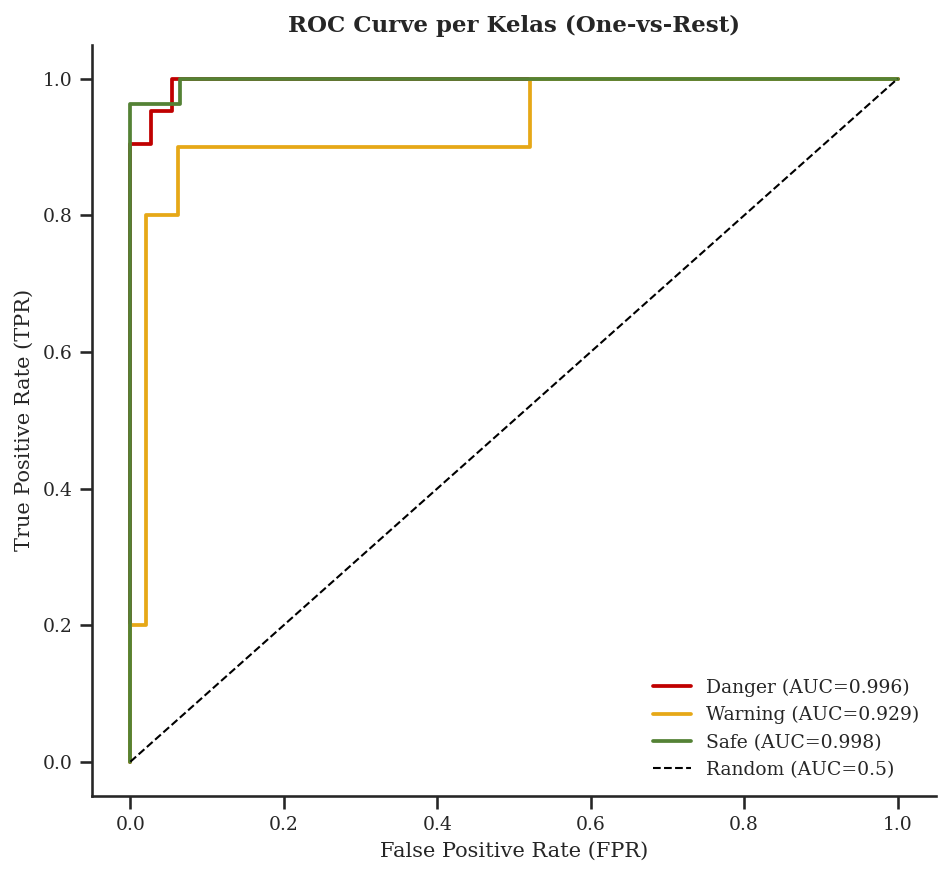

In [22]:
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize

# -- ROC Curve per kelas (One-vs-Rest) ---------------------------------------
y_test_binarized = label_binarize(
    y_clf_test_encoded, classes=list(range(len(CONFIG["risk_labels"])))
)
roc_colors = {"Danger": "#c00000", "Warning": "#e6a817", "Safe": "#548235"}

fig, ax = plt.subplots(figsize=(6.5, 6))
for k, label in enumerate(CONFIG["risk_labels"]):
    fpr_curve, tpr_curve, _ = roc_curve(y_test_binarized[:, k], y_clf_pred_proba[:, k])
    auc_k = auc(fpr_curve, tpr_curve)
    ax.plot(fpr_curve, tpr_curve, color=roc_colors.get(label, "#4472c4"),
            linewidth=1.8, label=f"{label} (AUC={auc_k:.3f})")
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1.0, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve per Kelas (One-vs-Rest)", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "03c_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

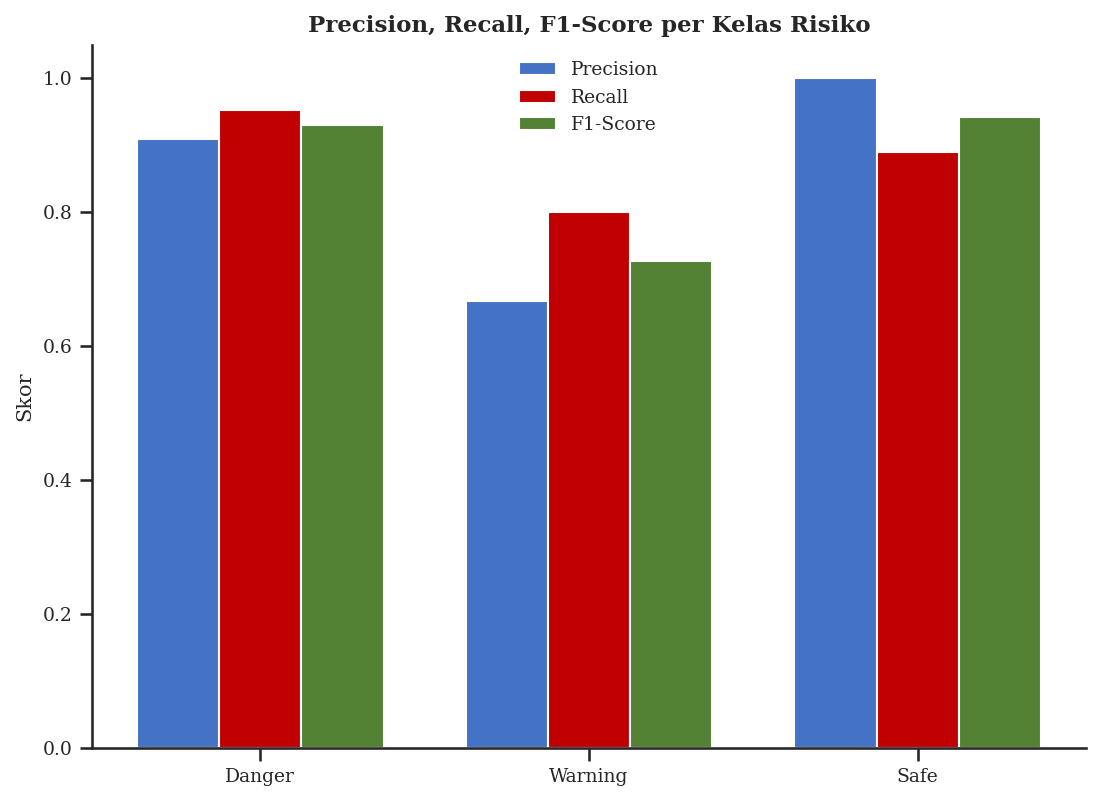


Metrik per kelas:
  Kelas  Precision  Recall  F1-Score
 Danger     0.9091  0.9524    0.9302
Warning     0.6667  0.8000    0.7273
   Safe     1.0000  0.8889    0.9412


In [23]:
# -- Precision / Recall / F1 per kelas (bar chart) ---------------------------
precision_k, recall_k, f1_k, support_k = precision_recall_fscore_support(
    y_clf_test_encoded, y_clf_pred_encoded, labels=list(range(len(CONFIG["risk_labels"])))
)
per_class_df = pd.DataFrame({
    "Kelas": CONFIG["risk_labels"], "Precision": precision_k,
    "Recall": recall_k, "F1-Score": f1_k,
})

x = np.arange(len(CONFIG["risk_labels"]))
width = 0.25
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(x - width, per_class_df["Precision"], width, label="Precision", color="#4472c4")
ax.bar(x, per_class_df["Recall"], width, label="Recall", color="#c00000")
ax.bar(x + width, per_class_df["F1-Score"], width, label="F1-Score", color="#548235")
ax.set_xticks(x)
ax.set_xticklabels(CONFIG["risk_labels"])
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.05)
ax.set_title("Precision, Recall, F1-Score per Kelas Risiko", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "03d_per_class_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMetrik per kelas:")
print(per_class_df.round(4).to_string(index=False))

---
### SECTION 14 — PERBANDINGAN MODEL: DENGAN VS TANPA MONOTONIC CONSTRAINT

**PENJELASAN**

Melatih satu model XGBoost TAMBAHAN dengan hyperparameter yang identik namun TANPA monotonic constraint, lalu membandingkan performanya terhadap model final -- untuk mengukur secara eksplisit berapa besar "biaya" (jika ada) dari memaksakan model mengikuti prinsip mekanika tanah.

**DASAR / JUSTIFIKASI ILMIAH**

Mengikuti gaya perbandingan/ranking antar-varian model pada studi M5Rules-GA (*Prediction of Slope Failure in Open-Pit Mines*). Constraint yang mengorbankan sedikit performa numerik demi konsistensi fisika yang terjamin adalah trade-off yang dapat dipertanggungjawabkan secara ilmiah -- TAPI ini harus DITUNJUKKAN secara kuantitatif dengan model pembanding nyata, bukan diasumsikan tidak berdampak.

**MEKANISME**

Model pembanding (`unconstrained_regressor`) memakai `BEST_PARAMS_REGRESSION` yang SAMA PERSIS (hyperparameter tidak diubah), hanya `monotone_constraints` diset semuanya ke 0 (tanpa constraint). Physics Inconsistency Index (didefinisikan Section 9) dihitung untuk kedua model sebagai dasar perbandingan konsistensi fisika.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [24]:
unconstrained_regressor = xgb.XGBRegressor(
    objective="reg:squarederror",
    monotone_constraints=tuple([0] * len(CONFIG["features"])),
    random_state=RANDOM_SEED,
    n_jobs=-1,
    **BEST_PARAMS_REGRESSION,
)
unconstrained_regressor.fit(X_train, y_reg_train)
y_pred_unconstrained = unconstrained_regressor.predict(X_test)

pi_unconstrained = compute_physics_inconsistency_index(y_reg_test.values, y_pred_unconstrained)

comparison_table = pd.DataFrame([
    {
        "Model": "XGBoost + Monotonic Constraint (Final)",
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "VAF (%)": vaf,
        "Physics Inconsistency Index": pi_index,
        "Ranking Fisika": 1 if pi_index <= pi_unconstrained else 2,
    },
    {
        "Model": "XGBoost Tanpa Constraint (Baseline)",
        "R2": r2_score(y_reg_test, y_pred_unconstrained),
        "RMSE": float(np.sqrt(mean_squared_error(y_reg_test, y_pred_unconstrained))),
        "MAE": float(mean_absolute_error(y_reg_test, y_pred_unconstrained)),
        "VAF (%)": compute_vaf(y_reg_test.values, y_pred_unconstrained),
        "Physics Inconsistency Index": pi_unconstrained,
        "Ranking Fisika": 1 if pi_unconstrained <= pi_index else 2,
    },
])

print("\n" + "=" * 70)
print("TABEL PERBANDINGAN: DENGAN VS TANPA MONOTONIC CONSTRAINT")
print("=" * 70)
print(comparison_table.round(5).to_string(index=False))

r2_diff = r2 - r2_score(y_reg_test, y_pred_unconstrained)
print(f"\nSelisih R2 (constraint - unconstrained): {r2_diff:+.4f}")
print(f"Selisih Physics Inconsistency Index    : {pi_index - pi_unconstrained:+.5f}")
print(f"\nInterpretasi: {'Constraint TIDAK mengorbankan performa berarti sambil meningkatkan' if abs(r2_diff) < 0.02 else 'Terdapat trade-off performa'} "
      f"konsistensi fisika model.")

comparison_table.to_csv(CONFIG["output_dir"] / "model_comparison_table.csv", index=False)


TABEL PERBANDINGAN: DENGAN VS TANPA MONOTONIC CONSTRAINT
                                 Model      R2    RMSE     MAE  VAF (%)  Physics Inconsistency Index  Ranking Fisika
XGBoost + Monotonic Constraint (Final) 0.96305 0.08481 0.06254 96.39319                      0.03706               2
   XGBoost Tanpa Constraint (Baseline) 0.96273 0.08518 0.06689 96.27762                      0.03315               1

Selisih R2 (constraint - unconstrained): +0.0003
Selisih Physics Inconsistency Index    : +0.00391

Interpretasi: Constraint TIDAK mengorbankan performa berarti sambil meningkatkan konsistensi fisika model.


---
### SECTION 15 — METRIK EFISIENSI OPERASIONAL (RUNNING TIME)

**PENJELASAN**

Merangkum waktu komputasi kedua model (regresi & klasifikasi) -- waktu training model final dan waktu inferensi (prediksi) pada test set -- yang sudah diukur langsung di Section 8, 9A, 12, dan 13A.

**DASAR / JUSTIFIKASI ILMIAH**

Efisiensi komputasi adalah pertimbangan praktis penting untuk sistem yang dimaksudkan berjalan operasional (bagian dari sistem Hybrid NARX-XGBoost, lihat Ringkasan Eksekutif) -- model dengan akurasi tinggi tapi waktu inferensi terlalu lambat tidak layak untuk pemantauan real-time. XGBoost dipilih di antara alasan lain justru karena reputasinya sebagai model dengan inferensi sangat cepat dibanding model deep learning setara (Chen & Guestrin, 2016) -- metrik ini memverifikasi klaim tersebut secara kuantitatif pada kasus penelitian ini, bukan diasumsikan.

**MEKANISME**

Seluruh waktu diukur memakai `time.perf_counter()` (resolusi tinggi, tidak terpengaruh perubahan jam sistem), dibungkus langsung di sekitar pemanggilan `.fit()` dan `.predict()` masing-masing model -- pengukuran murni instrumentasi, TIDAK mengubah proses training/inferensi itu sendiri. Waktu inferensi turut dilaporkan per-sampel (dibagi jumlah baris test set) agar dapat diekstrapolasi ke skenario operasional dengan volume data berbeda.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [25]:
efficiency_summary = pd.DataFrame([
    {"Model": "Regresi FK", "Training Time (detik)": round(training_time_regressor_sec, 4),
     "Inference Time (detik)": round(inference_time_regressor_sec, 6),
     "Inference Time (ms/sampel)": round(inference_time_regressor_sec / len(X_test) * 1000, 4)},
    {"Model": "Klasifikasi Risiko", "Training Time (detik)": round(training_time_classifier_sec, 4),
     "Inference Time (detik)": round(inference_time_classifier_sec, 6),
     "Inference Time (ms/sampel)": round(inference_time_classifier_sec / len(X_test) * 1000, 4)},
])

print("\n" + "=" * 70)
print("METRIK EFISIENSI OPERASIONAL")
print("=" * 70)
print(efficiency_summary.to_string(index=False))
efficiency_summary.to_csv(CONFIG["output_dir"] / "efficiency_summary.csv", index=False)


METRIK EFISIENSI OPERASIONAL
             Model  Training Time (detik)  Inference Time (detik)  Inference Time (ms/sampel)
        Regresi FK                 0.1577                0.003869                      0.0667
Klasifikasi Risiko                 0.3018                0.007434                      0.1282


---
### SECTION 16 — SIMPAN MODEL, ARTEFAK, & EXPERIMENT LOG

**PENJELASAN**

Menyimpan kedua model terlatih (regresi & klasifikasi) ke disk dalam format yang dapat dimuat ulang tanpa training ulang, beserta log eksperimen lengkap (JSON) berisi seluruh hyperparameter dan hasil metrik.

**DASAR / JUSTIFIKASI ILMIAH**

Model yang telah terlatih menjadi komponen inti sistem hybrid NARX-XGBoost -- disimpan terstruktur agar siap dipakai untuk tahap integrasi backend tanpa mengulang seluruh proses tuning (yang memakan waktu, lihat Section 15). Experiment log memberi jejak audit lengkap yang dapat ditelusuri kembali kapan pun diperlukan untuk verifikasi atau publikasi.

**MEKANISME**

`save_model()` bawaan XGBoost menyimpan kedua model dalam format native. Experiment log JSON memuat metadata run, konfigurasi dataset, hyperparameter terbaik, seluruh metrik evaluasi (regresi, klasifikasi, efisiensi), ranking SHAP, dan hasil verifikasi monotonic constraint.

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [26]:
print("\n" + "=" * 70)
print("SIMPAN MODEL, ARTEFAK, & EXPERIMENT LOG")
print("=" * 70)

final_regressor.save_model(CONFIG["model_regression_path"])
final_classifier.save_model(CONFIG["model_classifier_path"])
print(f"Model regresi disimpan     : {CONFIG['model_regression_path']}")
print(f"Model klasifikasi disimpan : {CONFIG['model_classifier_path']}")

prediction_preview = pd.DataFrame({
    "fk_actual": y_reg_test.values,
    "fk_predicted": y_reg_pred,
    "risk_actual": y_clf_test.values,
    "risk_predicted": y_clf_pred,
})
prediction_preview.to_csv(CONFIG["output_dir"] / "prediction_preview_xgboost.csv", index=False)
print(f"Preview prediksi disimpan  : "
      f"{CONFIG['output_dir'] / 'prediction_preview_xgboost.csv'}")

experiment_log = {
    "run_metadata": {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "project": "xgboost_disposal_fk_prediction",
        "version": "v1.0",
        "notes": (
            "XGBoost regresi FK + klasifikasi risiko, monotonic constraints, "
            "Bayesian tuning via Optuna, interpretasi SHAP. Disintesis dari "
            "13 referensi ilmiah (metodologi XGBoost, slope stability, SHAP, "
            "knowledge-guided ML)."
        ),
    },
    "dataset": {
        "path": str(CONFIG["csv_path"]),
        "n_rows_total": int(len(df)),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "features": CONFIG["features"],
        "monotone_constraints": CONFIG["monotone_constraints"],
    },
    "regression_model": {
        "best_hyperparameters": BEST_PARAMS_REGRESSION,
        "metrics": regression_metrics,
        "shap_feature_ranking": mean_abs_shap.to_dict("records"),
        "constraint_verification": constraint_verification,
    },
    "classification_model": {
        "best_hyperparameters": BEST_PARAMS_CLASSIFICATION,
        "metrics": classification_metrics,
        "risk_thresholds": CONFIG["risk_thresholds"],
    },
    "model_comparison": comparison_table.to_dict("records"),
    "operational_efficiency": efficiency_summary.to_dict("records"),
}

save_json(experiment_log, CONFIG["experiment_log_path"])
print(f"Experiment log disimpan    : {CONFIG['experiment_log_path']}")


SIMPAN MODEL, ARTEFAK, & EXPERIMENT LOG
Model regresi disimpan     : C:\Users\LOQ\TA_Mineplan\notebooks\models\XGBoost\XGBoost_Regressor_FK.json
Model klasifikasi disimpan : C:\Users\LOQ\TA_Mineplan\notebooks\models\XGBoost\XGBoost_Classifier_Risk.json
Preview prediksi disimpan  : C:\Users\LOQ\TA_Mineplan\notebooks\outputs\XGBoost\prediction_preview_xgboost.csv
Experiment log disimpan    : C:\Users\LOQ\TA_Mineplan\notebooks\logs\XGBoost\experiment_log.json


---
### SECTION 17 — SUMMARY & STATUS KELAYAKAN MODEL

**PENJELASAN**

Ringkasan akhir yang membandingkan setiap metrik utama terhadap target yang telah ditetapkan SEBELUM evaluasi dilakukan (Section 2), disajikan dalam satu tabel Parameter-Target-Hasil-Status, diikuti satu kesimpulan kelayakan.

**DASAR / JUSTIFIKASI ILMIAH**

Menetapkan target evaluasi SEBELUM melihat hasil (Section 2) lalu membandingkannya secara objektif di sini menghindari bias *post-hoc rationalization* (menyesuaikan standar kelulusan setelah tahu hasilnya). Ringkasan yang padat memudahkan pembimbing/penguji menilai kelayakan model secara cepat tanpa harus menelusuri seluruh 17 section.

**MEKANISME**

Setiap baris membandingkan satu metrik terhadap target di CONFIG, status "Lulus"/"Belum Lulus" ditentukan otomatis dari perbandingan numerik langsung (bukan penilaian subjektif).

**IMPLEMENTASI**

Lihat sel kode di bawah.

In [27]:
summary_rows = [
    {"Parameter": "R2 (Regresi)", "Target": f">= {CONFIG['threshold_r2']}",
     "Hasil Model": f"{r2:.4f}",
     "Status": "Lulus" if r2 >= CONFIG["threshold_r2"] else "Belum Lulus"},
    {"Parameter": "RMSE (Regresi)", "Target": "Serendah mungkin",
     "Hasil Model": f"{rmse:.4f}", "Status": "Informatif"},
    {"Parameter": "Accuracy (Klasifikasi)", "Target": "Tinggi (kontekstual)",
     "Hasil Model": f"{accuracy:.4f}", "Status": "Informatif"},
    {"Parameter": "Cohen's Kappa (Klasifikasi)",
     "Target": f">= {CONFIG['threshold_kappa']} (Moderate+)",
     "Hasil Model": f"{kappa:.4f} ({kappa_interpretation})",
     "Status": "Lulus" if kappa >= CONFIG["threshold_kappa"] else "Belum Lulus"},
    {"Parameter": "F1-Score (macro)", "Target": f">= {CONFIG['threshold_f1']}",
     "Hasil Model": f"{f1_macro:.4f}",
     "Status": "Lulus" if f1_macro >= CONFIG["threshold_f1"] else "Belum Lulus"},
    {"Parameter": "AUC-ROC (OvR, macro)", "Target": f">= {CONFIG['threshold_auc']}",
     "Hasil Model": f"{auc_ovr:.4f}",
     "Status": "Lulus" if auc_ovr >= CONFIG["threshold_auc"] else "Belum Lulus"},
    {"Parameter": "TPR / Recall (macro)", "Target": f">= {CONFIG['threshold_tpr']}",
     "Hasil Model": f"{tpr_macro:.4f}",
     "Status": "Lulus" if tpr_macro >= CONFIG["threshold_tpr"] else "Belum Lulus"},
    {"Parameter": "FPR (macro)", "Target": f"<= {CONFIG['threshold_fpr']}",
     "Hasil Model": f"{fpr_macro:.4f}",
     "Status": "Lulus" if fpr_macro <= CONFIG["threshold_fpr"] else "Belum Lulus"},
    {"Parameter": "Training Time (Regresi)", "Target": "Informatif",
     "Hasil Model": f"{training_time_regressor_sec:.4f} detik", "Status": "Informatif"},
    {"Parameter": "Inference Time (Regresi)", "Target": "Informatif",
     "Hasil Model": f"{inference_time_regressor_sec / len(X_test) * 1000:.4f} ms/sampel",
     "Status": "Informatif"},
    {"Parameter": "Training Time (Klasifikasi)", "Target": "Informatif",
     "Hasil Model": f"{training_time_classifier_sec:.4f} detik", "Status": "Informatif"},
    {"Parameter": "Inference Time (Klasifikasi)", "Target": "Informatif",
     "Hasil Model": f"{inference_time_classifier_sec / len(X_test) * 1000:.4f} ms/sampel",
     "Status": "Informatif"},
]
summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("SUMMARY & STATUS KELAYAKAN MODEL")
print("=" * 70)
print(summary_df.to_string(index=False))
summary_df.to_csv(CONFIG["output_dir"] / "final_summary_table.csv", index=False)

n_lulus = sum(1 for r in summary_rows if r["Status"] == "Lulus")
n_total_criteria = sum(1 for r in summary_rows if r["Status"] in ("Lulus", "Belum Lulus"))

print(f"\nKEPUTUSAN AKHIR: Model memenuhi {n_lulus}/{n_total_criteria} "
      f"kriteria evaluasi bertarget "
      f"({'LAYAK DIGUNAKAN' if n_lulus == n_total_criteria else 'PERLU PENINJAUAN LEBIH LANJUT pada kriteria yang belum lulus'}).")


SUMMARY & STATUS KELAYAKAN MODEL
                   Parameter               Target             Hasil Model     Status
                R2 (Regresi)               >= 0.8                  0.9630      Lulus
              RMSE (Regresi)     Serendah mungkin                  0.0848 Informatif
      Accuracy (Klasifikasi) Tinggi (kontekstual)                  0.8966 Informatif
 Cohen's Kappa (Klasifikasi)   >= 0.6 (Moderate+) 0.8369 (Almost Perfect)      Lulus
            F1-Score (macro)               >= 0.6                  0.8662      Lulus
        AUC-ROC (OvR, macro)               >= 0.7                  0.9743      Lulus
        TPR / Recall (macro)               >= 0.6                  0.8804      Lulus
                 FPR (macro)               <= 0.3                  0.0458      Lulus
     Training Time (Regresi)           Informatif            0.1577 detik Informatif
    Inference Time (Regresi)           Informatif        0.0667 ms/sampel Informatif
 Training Time (Klasifikasi)   